# ❗ 6. SKHynix PBL XAI 적용 - 딥러닝 모델❗


## 📌 개요

학습 완료된 머신러닝과 딥러닝 모델로부터 XAI 기법 적용하여 주요 변수 찾기

**데이터 입력 구조 및 XAI 해석 방식**:
- **머신러닝 모델**:  
    - 앙상블 계열 모델 내부 변수 별 중요도는 그 자체로 판단
    - SHAP value: 예측값이 증가/감소 하는데 영향을 주는 변수 확인
- **딥러닝 모델**: 예측값이 증가/감소 하는데 영향을 주는 전체 입력 값 중 특정 위치의 oper_id (만약 special 토큰 추가 시, special 토큰도 해당 될 수 있음)

**주요 사항**:
- **머신러닝 모델**:
    - 기본적으로 scikit-learn 제공 모델 대상으로 진행됨
    - 앙상블 계열 모델(ex. Random Forest, GBM, AdaBoost 등) 자체적으로 변수 별 중요도 산출 가능함
    - XAI 기법 중 하나인 SHAP을 이용하여 확인
        - SHAP으로 앙상블 계열 모델에 대해서도 적용은 가능함  
        - SHAP 공식 문서 [[LINK](https://shap.readthedocs.io/en/latest/example_notebooks/tabular_examples/model_agnostic/Multioutput%20Regression%20SHAP.html)]

- **딥러닝 모델**:
    - captum의 Integrated Gradients 기반으로 수치예측에 대한 XAI 적용
    - captum 공식 문서[[LINK](https://captum.ai/)]

- **공통사항**
    - 딥러닝,머신러닝 모델 모두 학습이 완료된 것을 가정함 / 학습 완료된 모델 필요함

## 🔧 1. 환경 설정 및 라이브러리 준비

### SHAP, Captum 설치 필요

```python
pip install shap
pip install captum
```

In [1]:
"""사용 라이브러리"""
from typing import List, Dict, Tuple, Optional, Union
from types import SimpleNamespace
from collections import defaultdict
from datetime import datetime
import time
import os
import json
import argparse
import math
import warnings
import logging

# ====================
# 데이터 처리 및 분석
# ====================
import yaml
import pandas as pd
import numpy as np

# ====================
# 시각화
# ====================
import matplotlib.pyplot as plt
import seaborn as sns

# ====================
# 머신러닝 - 데이터 전처리
# ====================
from sklearn.preprocessing import (
    LabelEncoder, 
    OneHotEncoder,
    StandardScaler, 
    MinMaxScaler, 
    RobustScaler
)

# ====================
# 머신러닝 - 모델
# ====================
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, 
    GradientBoostingRegressor, 
    AdaBoostRegressor
)
import xgboost
import lightgbm

# ====================
# 머신러닝 - 모델 평가 및 선택
# ====================
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

# ====================
# PyTorch
# ====================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau, StepLR

# ====================
# XAI 라이브러리
# ====================
import shap
import captum

# ====================
# 진행상황 표시
# ====================
from tqdm import tqdm

# 경고 메시지 제어
warnings.filterwarnings('ignore')

/usr/local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 🥊 기본 cofiguration 설정

In [2]:
def load_config(config_dir: str = "configs") -> Dict:
    """YAML 설정 파일들을 통합하여 로드"""
    configs = {}
    config_files = ["dataset", "model", "training"]

    for file in config_files:
        config_path = os.path.join(config_dir, f"{file}.yaml")
        with open(config_path, "r", encoding="utf-8") as f:
            config = yaml.safe_load(f)
            configs.update(config)

    return configs


def set_random_seeds(seed: int = 42):
    """재현성을 위한 랜덤 시드 설정"""
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def setup_logging(log_file: str = "training.log"):
    """로깅 설정"""
    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s - %(levelname)s - %(message)s",
        handlers=[
            logging.FileHandler(log_file),
            logging.StreamHandler()
        ]
    )
    return logging.getLogger(__name__)

import os
import argparse
print(f"현재 위치:",os.getcwd())
os.chdir(os.getcwd())

parser = argparse.ArgumentParser(description="XAI 기반 주요 인자 분석")
parser.add_argument("--config-dir", default="./configs/", help="설정 파일 디렉토리")
parser.add_argument("--mode", default="eval", help="딥러닝 모델은 이미 학습이 완료된 것을 가정")
parser.add_argument("--model-path", default="/home/doyoon/teaching/SKhynix_2025/SKhynix_week5/opertransformer/results/250913_test/transformer_20250913_063334.pth", help="평가용 모델 경로")
parser.add_argument("--gpu", type=int, default=0, help="GPU 번호")
parser.add_argument("--exp-name", default=None, help="실험명")

args = parser.parse_args([])


# 설정 로드
config = load_config(args.config_dir)
set_random_seeds(42)

# 실험명 설정
if args.exp_name:
    exp_name = args.exp_name
else:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_type = config.get("model_type", "default_model")
    exp_name = f"{model_type}_{timestamp}"

# 저장 디렉토리
save_dir = os.path.join("results", config.get("save_dir", "default"))
os.makedirs(save_dir, exist_ok=True)

# logger 설정
logger = setup_logging(os.path.join(save_dir, "deeplearning.log"))


현재 위치: /home/doyoon/teaching/SKhynix_2025/SKhynix_week6


# 🗂️ 시퀀스 데이터셋 클래스

## 범주형 데이터 처리기

## 메인 데이터셋

* `datasets.py` 확인
* 5주차와 동일한 데이터셋 활용

```python
def create_dataloaders(config: Dict) -> Tuple[DataLoader, DataLoader, DataLoader]:
```
이전에는 하나의 함수로 구성했으나 사용의 편의상 한줄씩 실행되도록 함

In [3]:
from datasets import GroupedOperDataset, split_data_by_days, custom_collate_fn, CategoricalProcessor

# 디바이스 설정
args.gpu = 1
device = torch.device(f"cuda:{args.gpu}" if torch.cuda.is_available() else "cpu")
logger.info(f"Using device: {device}")

# 데이터로더 생성
logger.info("데이터 로딩 중...")

# def create_dataloaders(config: Dict) -> Tuple[DataLoader, DataLoader, DataLoader]:

# 데이터 로드 및 전처리
data_path = config["file_path"]  # 설정에서 파일 경로 가져오기
# nrows는 테스트용이므로 꼭 제거 ! (주의사항 메모)
# Excel 파일의 모든 시트를 딕셔너리로 읽기, 두 번째 행을 헤더로 사용
excel = pd.read_excel(data_path, sheet_name=None, header=1)
sheet_names = config["sheet_names"]  # 사용할 시트 이름 목록 가져오기

# 지정된 시트들의 데이터를 하나의 데이터프레임으로 결합
total_df = pd.concat([excel[sheet_name] for sheet_name in sheet_names])

# 각 그룹(oper_group)별로 속한 공정(oper_id)들의 고유 값을 딕셔너리로 생성
group_to_opers = total_df.groupby('oper_group')['oper_id'].unique().to_dict()
# 전체 고유 그룹 수 계산
unique_groups_num = len(total_df['oper_group'].unique().tolist())

# 기본 전처리
# "Unnamed: 0" 컬럼이 있으면 제거 (Excel 읽기 시 생성되는 인덱스 컬럼)
if "Unnamed: 0" in total_df.columns:
    total_df.drop(columns="Unnamed: 0", inplace=True)

# y값 결측치 제거
# 타겟 컬럼에 결측치가 없는 행만 선택하여 복사본 생성
df = total_df[~total_df[config["target_column"]].isna()].copy()

# 불필요한 컬럼 제거
# 설정에서 추가로 제거할 컬럼 목록 가져오기 (없으면 빈 리스트)
drop_columns = config.get("additional_drop_columns", [])
if drop_columns:  # 제거할 컬럼이 있으면
    # 실제로 데이터프레임에 존재하는 컬럼만 필터링
    existing_drops = [col for col in drop_columns if col in df.columns]
    if existing_drops:  # 존재하는 컬럼이 있으면
        df = df.drop(columns=existing_drops)  # 해당 컬럼들 제거

# 인덱스 재설정 (0부터 시작하는 연속 인덱스로 변경)
df.reset_index(drop=True, inplace=True)

# ========================================
# 데이터 전처리 (정규화 전): NaN, Inf 제거
# ========================================

continuous_columns = config["continuous_columns"]
categorical_columns = config["categorical_columns"]
target_column = config["target_column"]

logger.info("데이터 전처리 시작...")

# NaN 체크 및 처리
nan_count = df[continuous_columns].isna().sum().sum()
if nan_count > 0:
    logger.warning(f"연속형 변수에 {nan_count}개의 NaN 발견! 0으로 대체합니다.")
    df[continuous_columns] = df[continuous_columns].fillna(0)

# Inf 체크 및 제거
inf_mask = np.isinf(df[continuous_columns].values)
if inf_mask.any():
    logger.warning(f"Inf 값 발견! 제거합니다.")
    df[continuous_columns] = df[continuous_columns].replace([np.inf, -np.inf], np.nan)
    df[continuous_columns] = df[continuous_columns].fillna(0)
    
# ========================================
# 범주형 변수 처리 (분할 전에 전체 데이터로)
# ========================================

# 범주형 처리기는 전체 데이터로 학습 (모든 카테고리를 알아야 함)
categorical_processor = CategoricalProcessor(
    embedding_dim=config.get("embedding_dim", 8)
)
categorical_processor.fit(df, categorical_columns)
df = categorical_processor.transform(df)

# ========================================
# 데이터 분할
# ========================================

# 데이터 분할 (8:1:1)
# 날짜 기준으로 시계열 데이터를 train, validation, test로 분할
train_df, val_df, test_df = split_data_by_days(
    df,
    train_ratio=config.get("train_ratio", 0.8),  # 학습 데이터 비율 (기본값: 0.8)
    val_ratio=config.get("val_ratio", 0.1),      # 검증 데이터 비율 (기본값: 0.1)
    test_ratio=config.get("test_ratio", 0.1)      # 테스트 데이터 비율 (기본값: 0.1)
)

# ========================================
# 연속형 변수 정규화
# ========================================

logger.info("연속형 변수 정규화")

# 1. 극단값 클리핑 (각 데이터셋 별도 처리)
if config.get("clip_outliers", True):
    logger.info("극단값 클리핑 적용...")
    
    # Train 데이터의 분위수로 클리핑 범위 결정
    clip_values = {}
    for col in continuous_columns:
        q01 = train_df[col].quantile(0.01)
        q99 = train_df[col].quantile(0.99)
        clip_values[col] = (q01, q99)
        
        # 모든 데이터셋에 동일한 클리핑 적용
        train_df[col] = train_df[col].clip(q01, q99)
        val_df[col] = val_df[col].clip(q01, q99)
        test_df[col] = test_df[col].clip(q01, q99)
        
        logger.debug(f"  {col}: [{q01:.4f}, {q99:.4f}]로 클리핑")

# 2. Scaler 생성 및 학습 (train 데이터만 사용!)
scaler_type = config.get("scaler_type", "robust")

if scaler_type == "robust":
    continuous_scaler = RobustScaler()
    logger.info("RobustScaler 사용 (이상치에 강건, 중앙값과 IQR 기반)")
elif scaler_type == "standard":
    continuous_scaler = StandardScaler()
    logger.info("StandardScaler 사용 (평균 0, 표준편차 1)")
elif scaler_type == "minmax":
    # MinMaxScaler의 범위를 설정 가능하게
    feature_range = config.get("minmax_range", (0, 1))
    continuous_scaler = MinMaxScaler(feature_range=feature_range)
    logger.info(f"MinMaxScaler 사용 (범위: {feature_range[0]}~{feature_range[1]})")
else:
    logger.warning(f"알 수 없는 scaler_type: {scaler_type}. RobustScaler 사용")
    continuous_scaler = RobustScaler()

# Train 데이터로만 fit!
continuous_scaler.fit(train_df[continuous_columns])

# 모든 데이터에 transform 적용
train_df[continuous_columns] = continuous_scaler.transform(train_df[continuous_columns])
val_df[continuous_columns] = continuous_scaler.transform(val_df[continuous_columns])
test_df[continuous_columns] = continuous_scaler.transform(test_df[continuous_columns])

logger.info("Normalize done!")

# 3. 타겟 변수 정규화 (옵션 - 일반적으로 권장하지 않음)
target_scaler = None
if config.get("normalize_target", False):
    # 타겟에도 동일한 스케일러 타입 적용 가능
    target_scaler_type = config.get("target_scaler_type", "robust")
    
    if target_scaler_type == "robust":
        target_scaler = RobustScaler()
    elif target_scaler_type == "standard":
        target_scaler = StandardScaler()
    elif target_scaler_type == "minmax":
        target_range = config.get("target_minmax_range", (0, 1))
        target_scaler = MinMaxScaler(feature_range=target_range)
    else:
        target_scaler = RobustScaler()
    
    # Train 데이터로만 fit!
    target_scaler.fit(train_df[[target_column]])
    
    # 모든 데이터에 transform 적용
    train_df[target_column] = target_scaler.transform(train_df[[target_column]])
    val_df[target_column] = target_scaler.transform(val_df[[target_column]])
    test_df[target_column] = target_scaler.transform(test_df[[target_column]])
    
    logger.info(f"타겟 변수 정규화 완료 ({target_scaler_type})")
else:
    logger.info(f"타겟 변수 범위:")
    logger.info(f"  Train: [{train_df[target_column].min():.4f}, {train_df[target_column].max():.4f}]")
    logger.info(f"  Val: [{val_df[target_column].min():.4f}, {val_df[target_column].max():.4f}]")
    logger.info(f"  Test: [{test_df[target_column].min():.4f}, {test_df[target_column].max():.4f}]")


# 데이터셋 생성 - group_position 파라미터 추가
# 학습용 데이터셋 생성
train_dataset = GroupedOperDataset(
    df=train_df,  # 학습용 데이터프레임
    categorical_columns=config["categorical_columns"],  # 범주형 컬럼 목록
    continuous_columns=config["continuous_columns"],    # 연속형 컬럼 목록
    target_column=config["target_column"],              # 타겟 컬럼명
    group_map=group_to_opers,                          # 그룹-공정 매핑 정보
    window_size=config.get("window_size", 10),         # 윈도우 크기 (기본값: 10)
    window_stride=config.get("window_stride", 1),      # 윈도우 이동 간격 (기본값: 1)
    padding_value=config.get("padding_value", 0.0),    # 패딩 값 (기본값: 0.0)
    group_position=config.get("group_position", "middle")  # 그룹 결정 기준 위치 (기본값: "middle")
)

# 검증용 데이터셋 생성 (학습 데이터셋과 동일한 설정 사용)
val_dataset = GroupedOperDataset(
    df=val_df,  # 검증용 데이터프레임
    categorical_columns=config["categorical_columns"],
    continuous_columns=config["continuous_columns"], 
    target_column=config["target_column"],
    group_map=group_to_opers,
    window_size=config.get("window_size", 10),
    window_stride=config.get("window_stride", 1),
    padding_value=config.get("padding_value", 0.0),
    group_position=config.get("group_position", "middle")  # 추가
)

# 테스트용 데이터셋 생성 (학습 데이터셋과 동일한 설정 사용)
test_dataset = GroupedOperDataset(
    df=test_df,  # 테스트용 데이터프레임
    categorical_columns=config["categorical_columns"],
    continuous_columns=config["continuous_columns"],
    target_column=config["target_column"],
    group_map=group_to_opers,
    window_size=config.get("window_size", 10),
    window_stride=config.get("window_stride", 1),
    padding_value=config.get("padding_value", 0.0),
    group_position=config.get("group_position", "middle")  # 추가
)

# 데이터로더 생성
batch_size = config.get("batch_size", 32)  # 배치 크기 (기본값: 32)
num_workers = config.get("num_workers", 4)  # 데이터 로딩 워커 수 (기본값: 4)
# 그룹 참조 인덱스 계산 (그룹을 결정할 윈도우 내 위치)
ref_idx = train_dataset._get_group_reference_index(train_dataset.window_size)

# 학습용 데이터로더 생성
train_loader = DataLoader(
    train_dataset,              # 학습 데이터셋
    batch_size=batch_size,       # 배치 크기
    shuffle=True,                # 학습 시 데이터 섞기 활성화
    num_workers=num_workers,     # 병렬 데이터 로딩 워커 수
    pin_memory=True,             # GPU 메모리로 빠른 전송을 위한 고정 메모리 사용
    collate_fn=custom_collate_fn # 배치 데이터 결합 함수
)

# 검증용 데이터로더 생성
val_loader = DataLoader(
    val_dataset,                 # 검증 데이터셋
    batch_size=batch_size,       # 배치 크기
    shuffle=False,               # 검증 시 데이터 섞기 비활성화 (재현성)
    num_workers=num_workers,     # 병렬 데이터 로딩 워커 수
    pin_memory=True,             # GPU 메모리로 빠른 전송을 위한 고정 메모리 사용
    collate_fn=custom_collate_fn # 배치 데이터 결합 함수
)

# 테스트용 데이터로더 생성
test_loader = DataLoader(
    test_dataset,                # 테스트 데이터셋
    batch_size=batch_size,       # 배치 크기
    shuffle=False,               # 테스트 시 데이터 섞기 비활성화 (재현성)
    num_workers=num_workers,     # 병렬 데이터 로딩 워커 수
    pin_memory=True,             # GPU 메모리로 빠른 전송을 위한 고정 메모리 사용
    collate_fn=custom_collate_fn # 배치 데이터 결합 함수
)

# 데이터로더 생성 정보 로깅
logger.info(f"데이터로더 생성 완료:")
logger.info(f"  - 훈련 샘플: {len(train_dataset)}")     # 학습 데이터셋 크기
logger.info(f"  - 검증 샘플: {len(val_dataset)}")       # 검증 데이터셋 크기
logger.info(f"  - 테스트 샘플: {len(test_dataset)}")    # 테스트 데이터셋 크기
logger.info(f"  - 배치 크기: {batch_size}")             # 배치 크기
logger.info(f"  - 그룹 기준 위치: {config.get('group_position', 'first')}")  # 그룹 결정 위치

# 데이터로더 3개와 추가 정보 반환
# return train_loader, val_loader, test_loader, categorical_processor, ref_idx, unique_groups_num
# train_loader: 학습용 데이터로더
# val_loader: 검증용 데이터로더
# test_loader: 테스트용 데이터로더
# categorical_processor: 범주형 데이터 처리기 (추론 시 동일한 인코딩 적용)
# ref_idx: 그룹 참조 인덱스 (모델에서 사용)
# unique_groups_num: 고유 그룹 수 (모델 설계 참고용)

2025-09-14 14:44:31,335 - INFO - Using device: cuda:1
2025-09-14 14:44:31,336 - INFO - 데이터 로딩 중...
2025-09-14 14:58:12,351 - INFO - 데이터 전처리 시작...
2025-09-14 14:58:12,500 - WARNING - Inf 값 발견! 제거합니다.
2025-09-14 14:58:13,191 - INFO - 범주형 변수별 고유값 개수:
2025-09-14 14:58:13,192 - INFO -   oper_group: 277개
2025-09-14 14:58:13,193 - INFO -   days: 7개
2025-09-14 14:58:13,193 - INFO -   shift: 3개
2025-09-14 14:58:13,194 - INFO -   x1: 20개
2025-09-14 14:58:14,980 - INFO - 날짜 기준 데이터 분할 완료:
2025-09-14 14:58:14,981 - INFO -   - 총 날짜 수: 90일
2025-09-14 14:58:14,982 - INFO -   - Train: 72일 (1,342,808행)
2025-09-14 14:58:14,983 - INFO -   - Validation: 9일 (170,705행)
2025-09-14 14:58:14,984 - INFO -   - Test: 9일 (157,944행)
2025-09-14 14:58:14,985 - INFO -   - Train 날짜 범위: 20250503 ~ 20250713
2025-09-14 14:58:14,986 - INFO -   - Val 날짜 범위: 20250714 ~ 20250722
2025-09-14 14:58:14,987 - INFO -   - Test 날짜 범위: 20250723 ~ 20250731
2025-09-14 14:58:14,988 - INFO - 연속형 변수 정규화
2025-09-14 14:58:14,989 - INFO - Stan

## OperTransformer모델
- models.py 확인
- 5주차와는 다르게 Integrated Gradients를 적용하기 위해서는 예측값만 출력되게 설정해야 함 (i.e. targets_out은 생략됨)

In [4]:
from models import VanillaTransformer

def create_model(config: Dict, vocab_sizes: List[int], continuous_dim: int, ref_idx:int, unique_groups_num: int):
    """설정에 따른 모델 생성"""
    
    # 모델 설정 딕셔너리 생성
    model_config = {
        # 데이터 차원 관련 설정
        "continuous_dim": continuous_dim,  # 연속형 변수의 차원 수
        "vocab_sizes": vocab_sizes,  # 각 범주형 변수의 어휘 크기 (임베딩 테이블 크기 결정)
        "output_type": config.get("output_type", 'sequence'),  # 출력 타입 ('sequence' 또는 'target', 기본값: 'sequence')
        "use_special_tokens": config.get("use_special_tokens", True),  # 특수 토큰 사용 여부 (기본값: True)
        
        # 모델 하이퍼파라미터
        "seq_len": config.get("seq_len", 100),  # 입력 시퀀스 길이 (기본값: 100)
        "pred_len": config.get("pred_len", 1),  # 예측 길이 (기본값: 1)
        "window_size": config.get("window_size", 10),  # 윈도우 크기 (기본값: 10)
        
        # Transformer 설정
        "d_model": config.get("d_model", 512),  # 모델의 히든 차원 (기본값: 512)
        "n_heads": config.get("n_heads", 8),  # 멀티헤드 어텐션의 헤드 수 (기본값: 8)
        "e_layers": config.get("e_layers", 3),  # Encoder 레이어 수 (기본값: 3)
        "d_ff": config.get("d_ff", 2048),  # Feed Forward 네트워크의 히든 차원 (기본값: 2048)
        
        # 임베딩 설정
        "embedding_dim": config.get("embedding_dim", 8),  # 범주형 변수 임베딩 차원 (기본값: 8)
        "ref_idx": ref_idx,  # 그룹 결정 참조 인덱스 (윈도우 내에서 어느 위치를 기준으로 할지)
        "num_groups": unique_groups_num,  # 전체 그룹 수 (그룹 임베딩 테이블 크기 결정)
        
        # 학습 설정
        "dropout": config.get("dropout", 0.1),  # 드롭아웃 비율 (기본값: 0.1)
        "activation": config.get("activation", "relu"),  # 활성화 함수 (기본값: "relu")
        "factor": config.get("factor", 5),  # ProbAttention의 factor 파라미터 (기본값: 5)
        
    }
    
    # 딕셔너리를 SimpleNamespace 객체로 변환 (점 표기법으로 접근 가능하게 함)
    # 예: model_config['d_model'] 대신 model_config.d_model로 접근 가능
    model_config = SimpleNamespace(**model_config)
    
    model = VanillaTransformer(model_config)
    
    logger.info(f"모델 생성 완료:")
    logger.info(f"  - 총 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")
    logger.info(f"  - 학습 가능한 파라미터 수: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    
    return model


### 학습된 모델 불러오기
- 저장한 모델의 모습과 동일하게 초기화(정의) 먼저 함
- 그 다음 저장된 모델 불러오기

In [5]:
# 모델 생성
vocab_sizes = categorical_processor.get_vocab_sizes()
continuous_dim = len(config["continuous_columns"])

model = create_model(config, vocab_sizes, continuous_dim, ref_idx, unique_groups_num)

logger.info(f"모델 로드: {args.model_path}")

# 모델 로드
checkpoint = torch.load(args.model_path, map_location=device)  # 체크포인트 로드
model.load_state_dict(checkpoint['model_state_dict'])  # 모델 가중치 로드

# 모델을 디바이스로 이동 및 평가 모드 설정
device = torch.device(f"cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()  # 평가 모드 (드롭아웃 비활성화, 배치정규화 고정)

2025-09-14 15:00:19,875 - INFO - 모델 생성 완료:
2025-09-14 15:00:19,876 - INFO -   - 총 파라미터 수: 1,497,625
2025-09-14 15:00:19,877 - INFO -   - 학습 가능한 파라미터 수: 1,497,625
2025-09-14 15:00:19,878 - INFO - 모델 로드: /home/doyoon/teaching/SKhynix_2025/SKhynix_week5/opertransformer/results/250913_test/transformer_20250913_063334.pth


VanillaTransformer(
  (data_embedding): DataEmbeddingWithCategorical(
    (categorical_embedding): CategoricalEmbedding(
      (embeddings): ModuleList(
        (0): Embedding(277, 8)
        (1): Embedding(7, 8)
        (2): Embedding(3, 8)
        (3): Embedding(20, 8)
      )
    )
    (input_projection): Linear(in_features=52, out_features=128, bias=True)
    (position_embedding): PositionalEmbedding()
    (dropout): Dropout(p=0.1, inplace=False)
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (encoder): Encoder(
    (attn_layers): ModuleList(
      (0-1): 2 x EncoderLayer(
        (attention): AttentionLayer(
          (inner_attention): FullAttention(
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (query_projection): Linear(in_features=128, out_features=128, bias=True)
          (key_projection): Linear(in_features=128, out_features=128, bias=True)
          (value_projection): Linear(in_features=128, out_features=128, bias=True

# 🆚 Captum 활용한 XAI 기법 비교

In [6]:
# imports from captum library
from captum.attr import LayerConductance, LayerActivation, LayerIntegratedGradients
from captum.attr import IntegratedGradients, KernelShap

### 하나의 batch 실행

In [7]:
batch  = next(iter(test_loader))
enc_out, attn_mask, targets, new_masks, timekeys, window_oper_ids, sequence_lengths, reference_oper_groups = model.get_inputs(batch, device)

print(f"enc_out shape: {enc_out.shape}")
print(f"attn_mask shape: {attn_mask.shape if attn_mask is not None else None}")

# # 모델 예측 수행
predictions = model(enc_out, attn_mask)


enc_out shape: torch.Size([16, 65, 128])
attn_mask shape: torch.Size([16, 1, 65, 65])


XAI 적용 위해 모델 구조 일부 변경

In [8]:
class FixedMaskModel(nn.Module):
    def __init__(self, original_model, fixed_mask):
        super().__init__()
        self.original_model = original_model
        self.fixed_mask = fixed_mask
        
    def forward(self, x):
        return self.original_model(x, self.fixed_mask)

# 고정된 마스크로 모델 래핑
wrapped_model = FixedMaskModel(model, attn_mask)

# baseline: 모든 feature를 0으로 설정
baseline = torch.zeros_like(enc_out)

# IntegratedGradients 적용
ig = IntegratedGradients(wrapped_model)
attributions = ig.attribute(
    inputs=enc_out,
    baselines=baseline,
    n_steps=50,
)

Oper IDs Length: 17, Valid Attr Length: 17
Sample 1 - 유효 시퀀스 길이: 17
Sample 1 - 중요도 합 (유효 위치): tensor([-0.0029, -0.0076, -0.0049, -0.0061, -0.0024, -0.0053, -0.0072, -0.0163,
        -0.0158, -0.0086,  0.0011,  0.0057,  0.0007,  0.0002, -0.0050, -0.0012,
         0.0014])


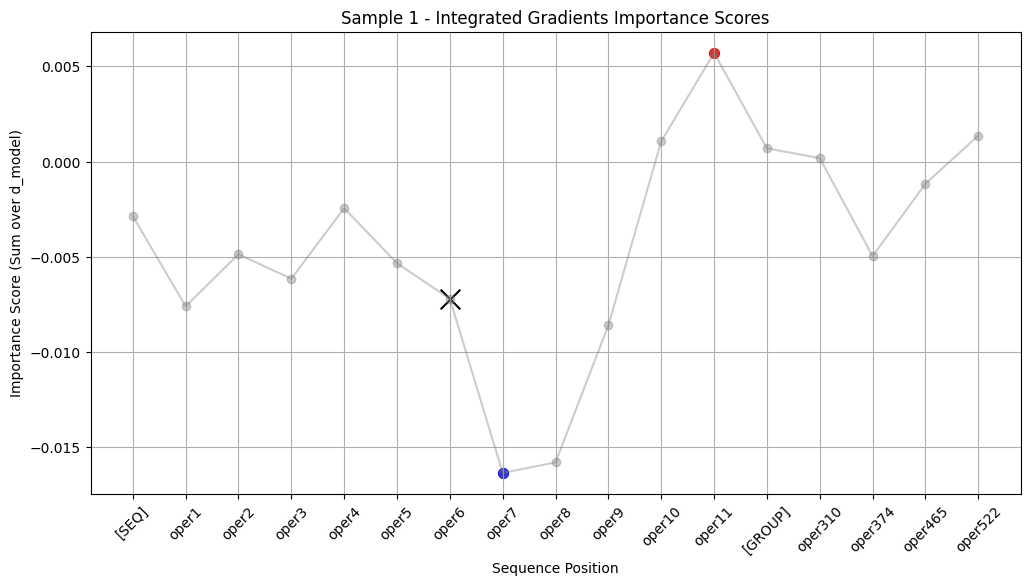

Oper IDs Length: 31, Valid Attr Length: 31
Sample 2 - 유효 시퀀스 길이: 31
Sample 2 - 중요도 합 (유효 위치): tensor([-1.9185e-03, -2.0828e-03, -2.8961e-03, -2.4196e-05, -2.3547e-03,
        -3.4214e-03, -1.1723e-01, -6.3973e-03, -4.0887e-03,  8.2323e-04,
         2.0670e-03,  2.1892e-05,  1.4104e-03, -2.5341e-03, -2.0780e-03,
        -1.9075e-03, -4.1268e-03, -4.4170e-03, -3.6491e-03, -4.0318e-03,
        -3.8782e-03, -2.6575e-03, -4.0837e-03, -2.5698e-03, -8.7644e-04,
        -5.2977e-03, -5.3256e-03, -5.2497e-03, -3.6000e-03, -4.5547e-03,
        -4.6006e-03])


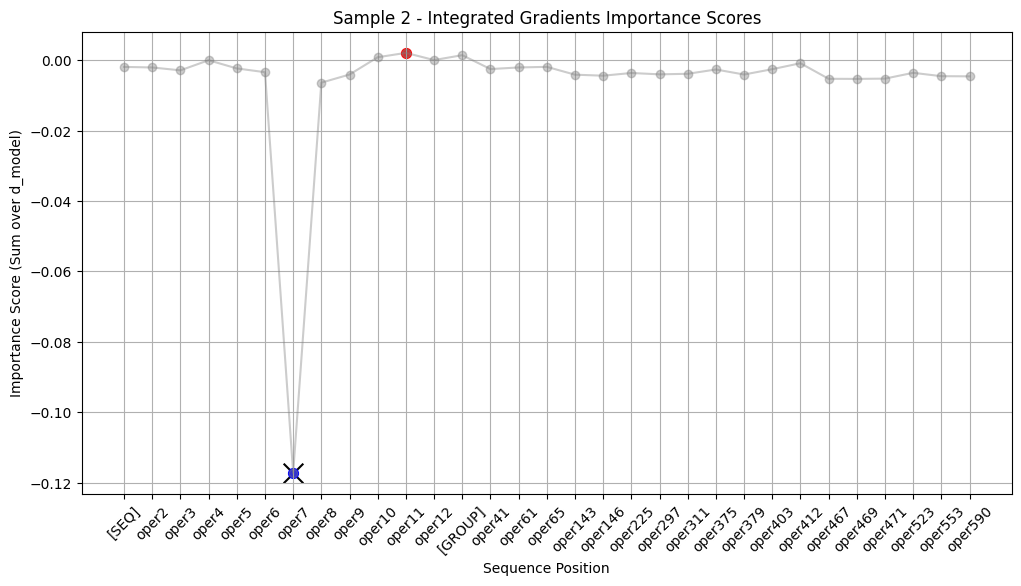

Oper IDs Length: 22, Valid Attr Length: 22
Sample 3 - 유효 시퀀스 길이: 22
Sample 3 - 중요도 합 (유효 위치): tensor([-0.0023, -0.0048,  0.0011, -0.0011, -0.0026, -0.0050, -0.0839, -0.0114,
        -0.0023,  0.0102,  0.0011,  0.0029, -0.0004,  0.0090, -0.0041, -0.0078,
        -0.0061, -0.0063, -0.0070, -0.0041, -0.0108, -0.0067])


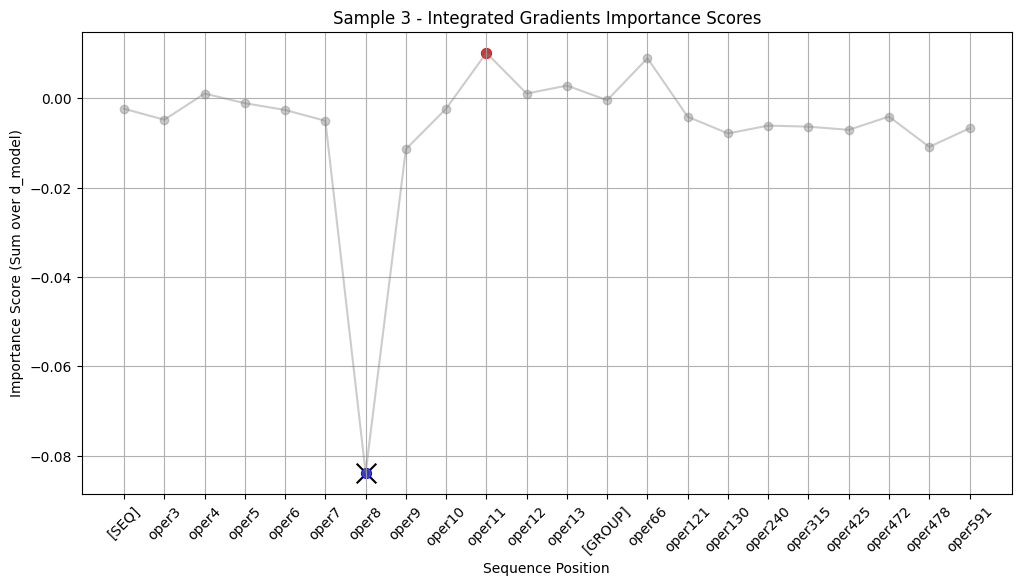

Oper IDs Length: 38, Valid Attr Length: 38
Sample 4 - 유효 시퀀스 길이: 38
Sample 4 - 중요도 합 (유효 위치): tensor([-3.5502e-03,  7.4052e-05, -6.8001e-04, -8.6397e-04, -3.0353e-03,
        -1.1502e-02, -7.6877e-02, -7.8694e-03,  1.9085e-02,  4.0917e-04,
         3.7630e-03,  3.9523e-03,  2.3924e-04, -5.0565e-03, -4.4329e-03,
        -3.4284e-03, -3.7966e-03,  7.7089e-03, -2.8562e-03, -3.7611e-03,
        -2.9134e-03, -3.5573e-03, -2.1223e-03, -3.3947e-03, -4.4181e-03,
        -2.1813e-03, -3.8837e-03, -2.1638e-03, -4.3911e-03, -2.5559e-03,
        -1.9377e-04, -1.6276e-03, -7.6123e-04, -4.8412e-03, -4.8691e-03,
        -4.6877e-03, -4.0904e-03, -4.9444e-03])


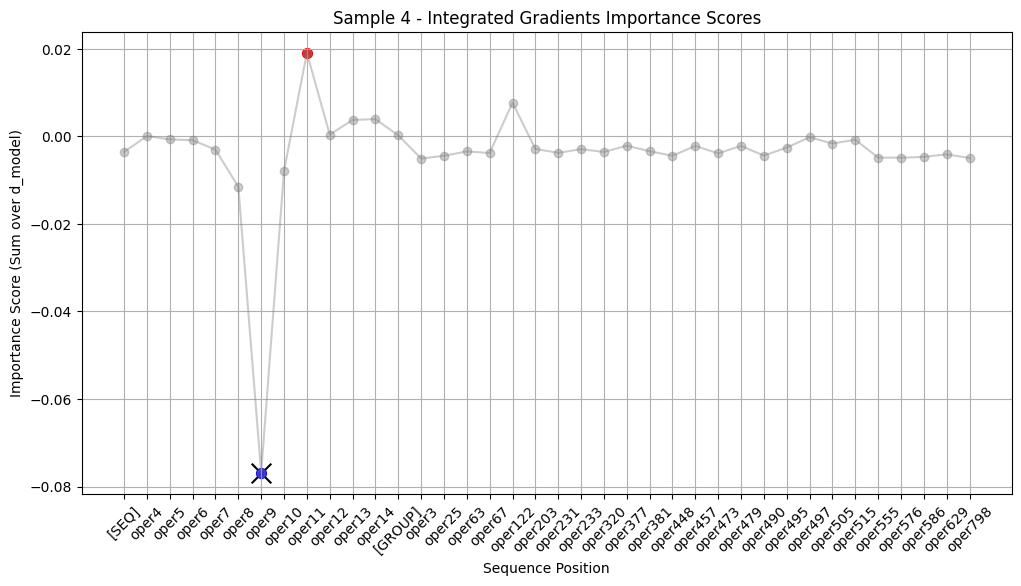

Oper IDs Length: 21, Valid Attr Length: 21
Sample 5 - 유효 시퀀스 길이: 21
Sample 5 - 중요도 합 (유효 위치): tensor([-0.0007, -0.0010, -0.0013, -0.0015, -0.0058, -0.0089, -0.1075,  0.0166,
        -0.0007,  0.0005,  0.0021, -0.0003,  0.0022,  0.0070,  0.0023,  0.0030,
         0.0107,  0.0067,  0.0026,  0.0060,  0.0019])


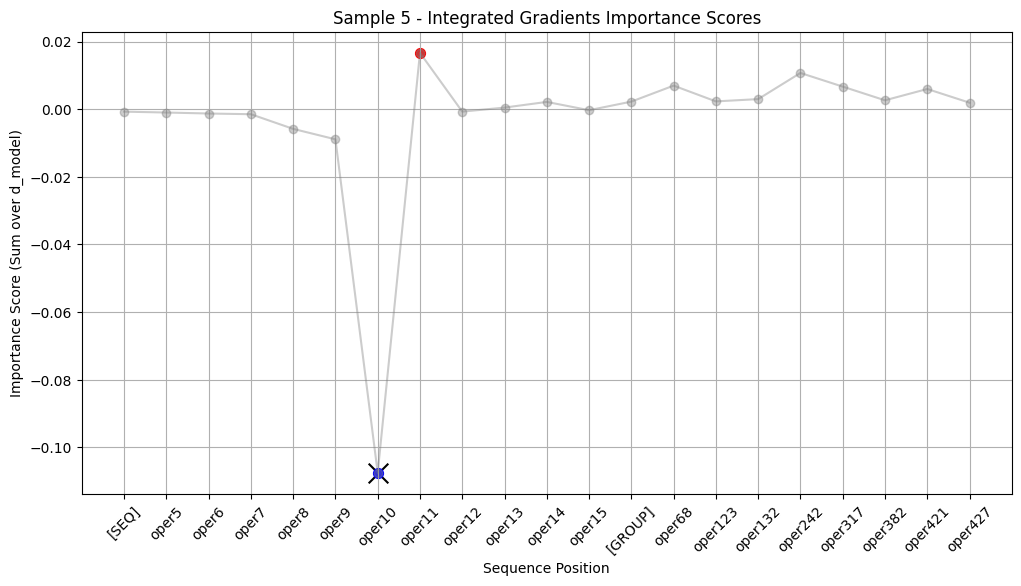

Oper IDs Length: 17, Valid Attr Length: 17
Sample 6 - 유효 시퀀스 길이: 17
Sample 6 - 중요도 합 (유효 위치): tensor([-0.0124, -0.0170, -0.0147, -0.0263, -0.0269, -0.0368,  0.6841, -0.0226,
        -0.0212, -0.0248, -0.0173, -0.0259,  0.2975,  0.0094,  0.0078,  0.0034,
        -0.0131])


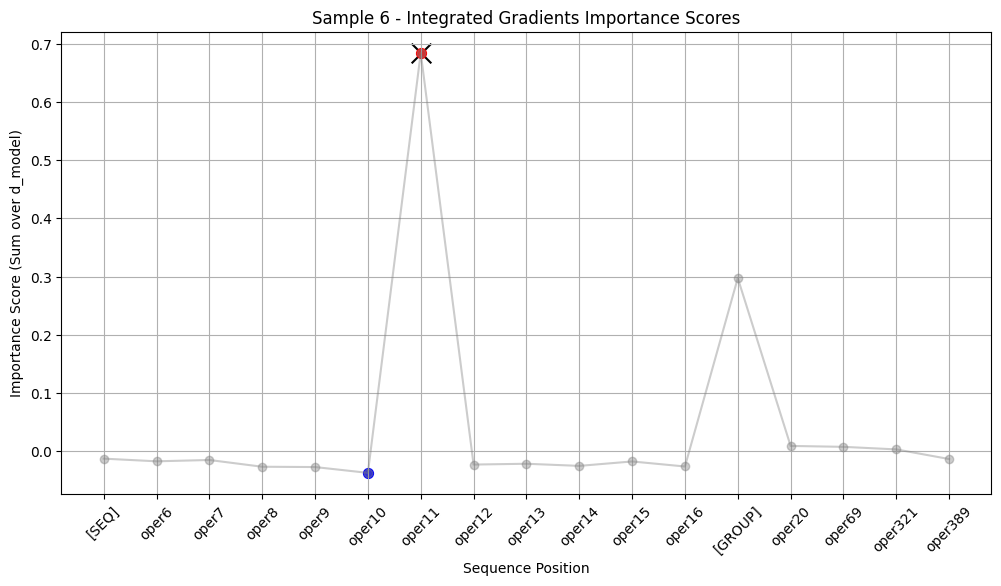

Oper IDs Length: 23, Valid Attr Length: 23
Sample 7 - 유효 시퀀스 길이: 23
Sample 7 - 중요도 합 (유효 위치): tensor([-5.6252e-03, -6.6473e-03, -7.9941e-03, -5.6350e-03, -6.4989e-03,
         5.4441e-03,  2.0767e-01, -8.2631e-03, -9.0793e-03,  8.7787e-03,
        -1.1495e-02, -9.4588e-03, -3.3669e-03,  2.8939e-03, -1.4012e-03,
         1.9685e-02,  1.0043e-02,  6.5663e-04, -8.5762e-04,  8.5504e-03,
         6.3925e-04, -1.9681e-04,  6.1748e-03])


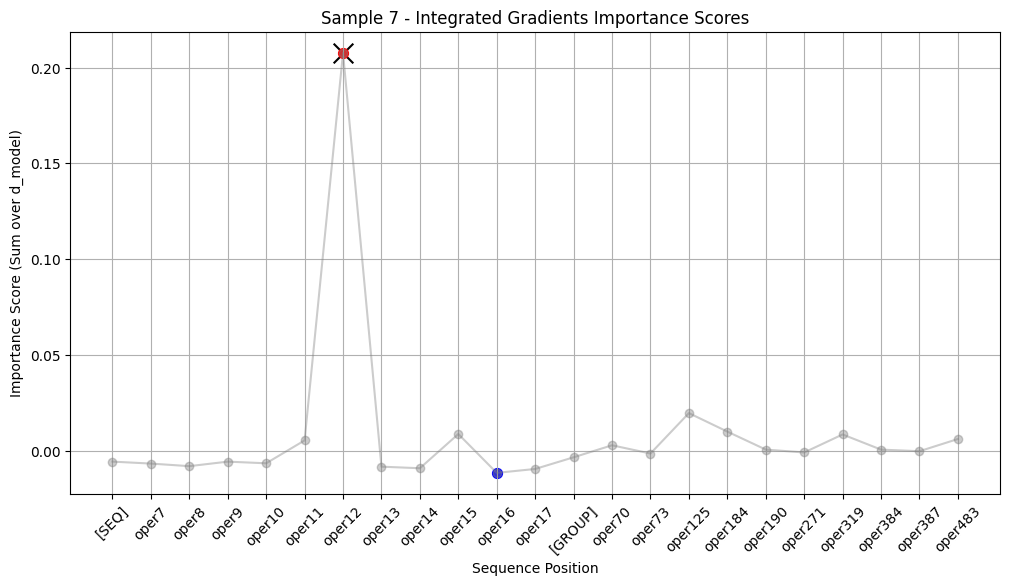

Oper IDs Length: 14, Valid Attr Length: 14
Sample 8 - 유효 시퀀스 길이: 14
Sample 8 - 중요도 합 (유효 위치): tensor([ 0.0007, -0.0071, -0.0054, -0.0037,  0.0033,  0.0011,  0.0609, -0.0080,
         0.0067, -0.0121, -0.0086, -0.0059,  0.0028,  0.0028])


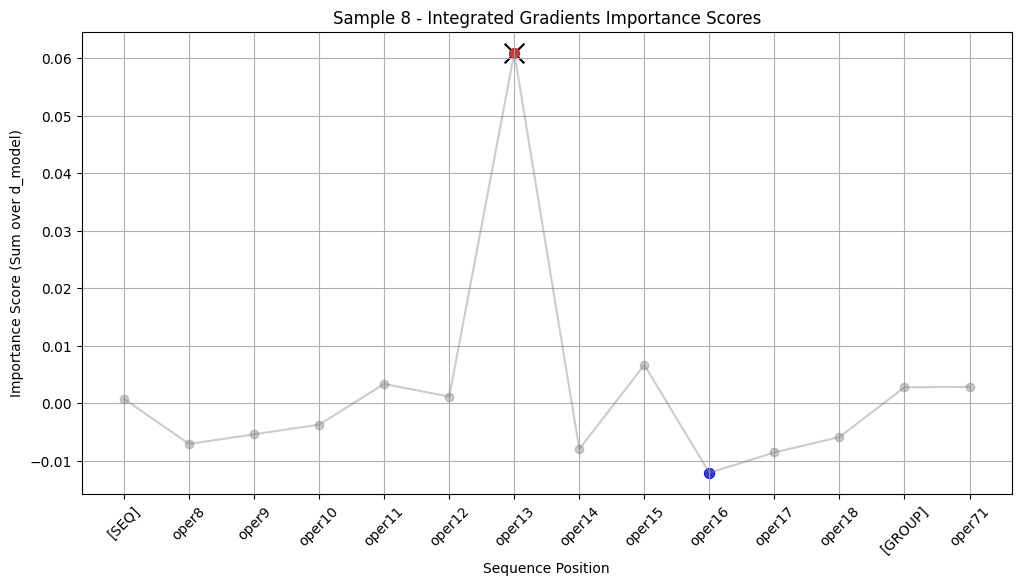

Oper IDs Length: 18, Valid Attr Length: 18
Sample 9 - 유효 시퀀스 길이: 18
Sample 9 - 중요도 합 (유효 위치): tensor([-0.0026, -0.0043, -0.0011,  0.0002, -0.0008, -0.0013, -0.0593,  0.0022,
        -0.0051, -0.0075, -0.0065, -0.0035, -0.0075,  0.0027, -0.0002, -0.0011,
        -0.0024, -0.0003])


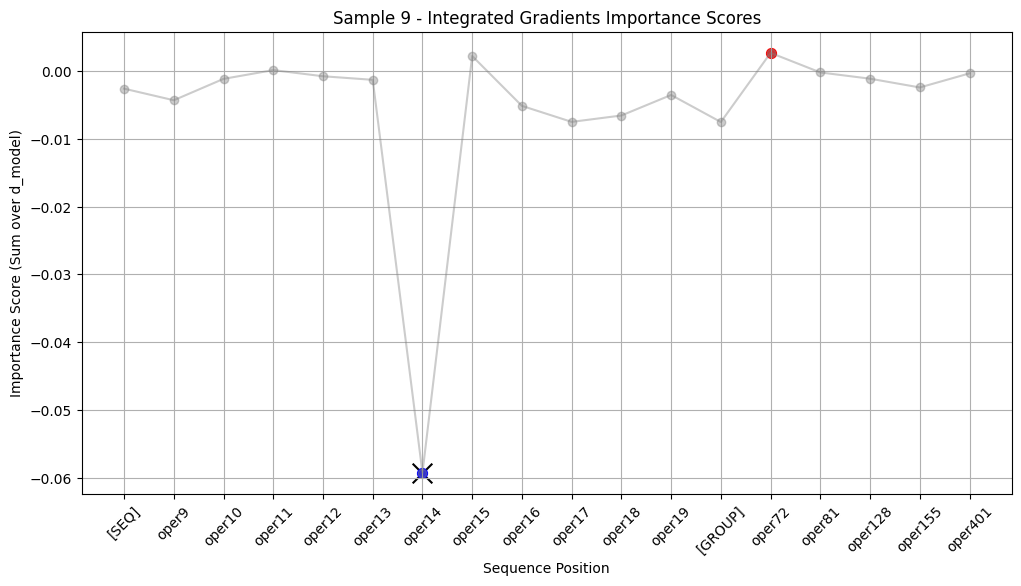

Oper IDs Length: 23, Valid Attr Length: 23
Sample 10 - 유효 시퀀스 길이: 23
Sample 10 - 중요도 합 (유효 위치): tensor([-0.0041, -0.0094,  0.0068, -0.0045, -0.0151, -0.0237,  0.5048, -0.0293,
        -0.0361, -0.0282, -0.0138,  0.0080, -0.0077, -0.0072, -0.0062,  0.0289,
         0.0438, -0.0012, -0.0037,  0.0108,  0.0035, -0.0048,  0.0194])


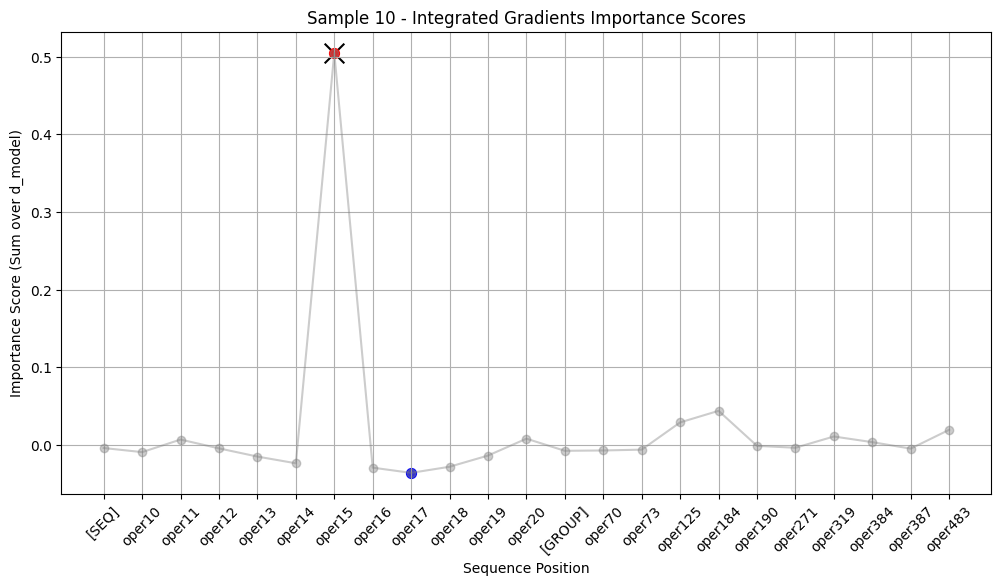

Oper IDs Length: 14, Valid Attr Length: 14
Sample 11 - 유효 시퀀스 길이: 14
Sample 11 - 중요도 합 (유효 위치): tensor([-0.0018,  0.0026,  0.0031,  0.0098,  0.0047,  0.0072,  0.0485, -0.0145,
        -0.0124, -0.0073,  0.0024, -0.0069,  0.0162,  0.0047])


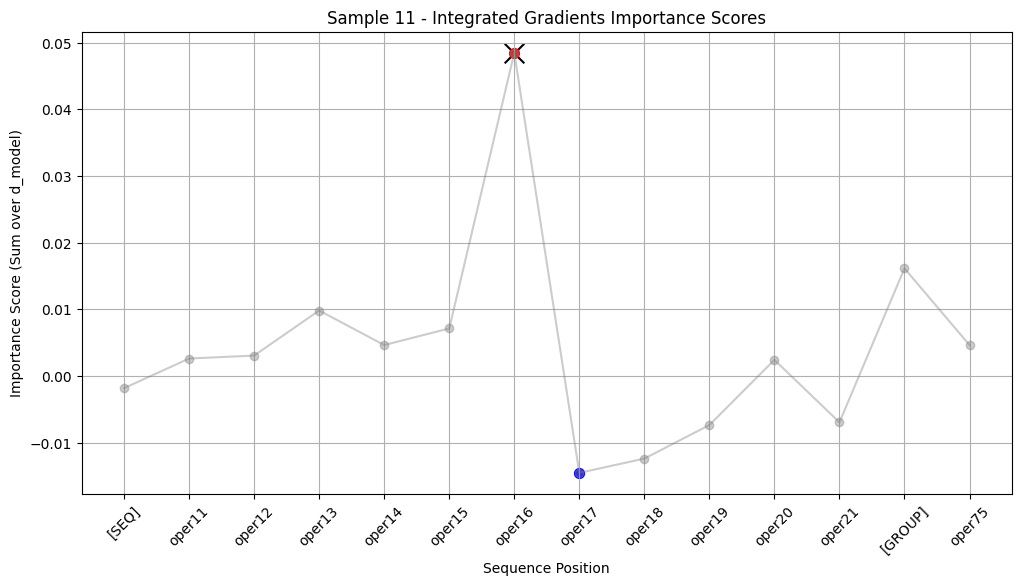

Oper IDs Length: 41, Valid Attr Length: 41
Sample 12 - 유효 시퀀스 길이: 41
Sample 12 - 중요도 합 (유효 위치): tensor([-2.2727e-03,  7.1803e-05,  1.5606e-03,  6.9677e-04,  6.7737e-04,
        -5.0308e-03, -1.1863e-01, -6.3945e-03, -4.1026e-03,  3.2265e-03,
        -4.2202e-03, -4.7256e-03,  1.4159e-03, -1.4729e-03, -1.7495e-03,
        -3.3515e-03, -4.1136e-03, -3.1128e-03, -4.0494e-03, -1.5717e-03,
        -4.0004e-03, -3.6380e-03, -2.2191e-03, -2.8240e-03, -7.6026e-04,
        -3.3901e-03, -3.8463e-03, -2.8192e-03, -2.9272e-03,  2.1373e-04,
        -3.5390e-03, -3.8140e-03, -1.4902e-03, -1.2436e-03, -3.0395e-03,
        -2.8593e-03, -2.6101e-03, -2.5759e-03, -3.5638e-03, -2.9998e-03,
        -2.0213e-03])


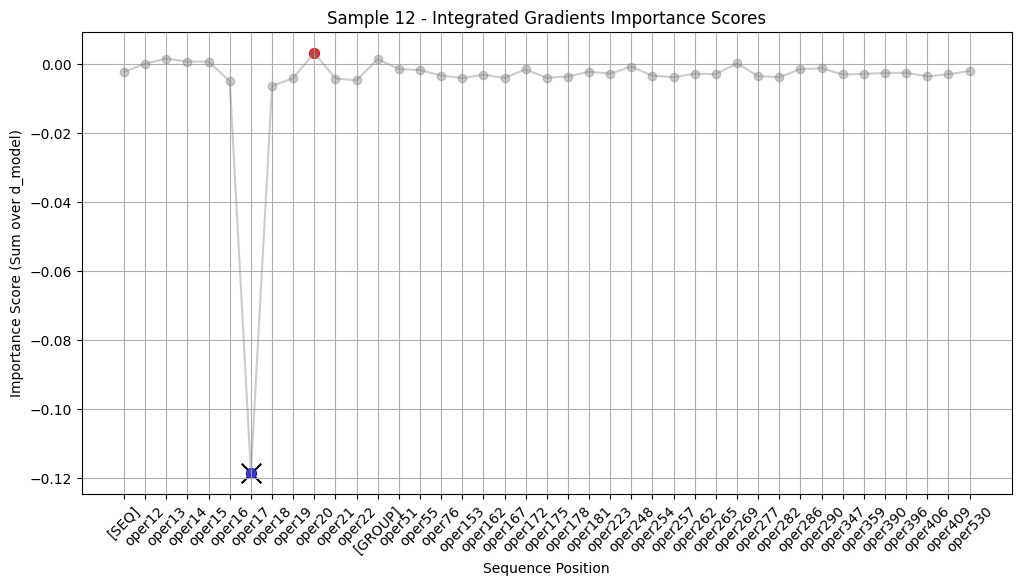

Oper IDs Length: 22, Valid Attr Length: 22
Sample 13 - 유효 시퀀스 길이: 22
Sample 13 - 중요도 합 (유효 위치): tensor([-2.9520e-03,  1.3971e-03,  1.1317e-03, -2.2489e-03, -6.4252e-03,
        -9.0743e-03, -5.9247e-02, -1.1034e-02,  1.8064e-02, -7.2132e-03,
        -7.1433e-03, -4.8532e-03, -2.4368e-03, -7.9792e-05, -7.7372e-04,
         5.9616e-03, -4.3924e-03, -4.4160e-03, -5.0980e-03, -3.7986e-03,
        -3.6913e-03, -8.8333e-03])


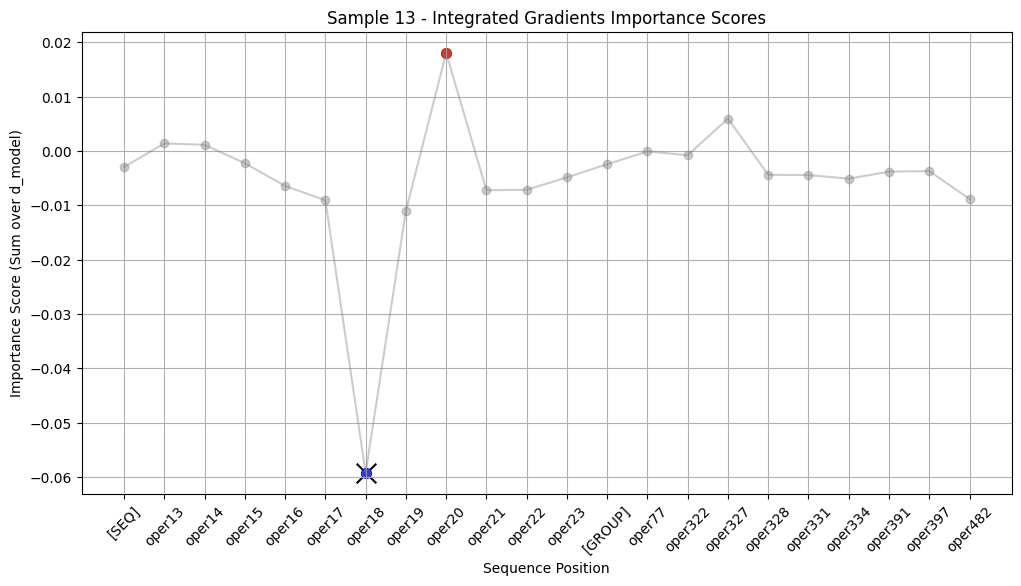

Oper IDs Length: 43, Valid Attr Length: 43
Sample 14 - 유효 시퀀스 길이: 43
Sample 14 - 중요도 합 (유효 위치): tensor([-3.0661e-03,  2.1963e-03,  1.6347e-03, -4.2646e-03, -4.2578e-03,
        -6.9779e-03, -1.0577e-01,  1.4753e-02, -1.1315e-02, -9.6406e-03,
        -5.5801e-03, -6.2747e-03,  4.9247e-04, -3.7792e-04,  1.1373e-03,
         2.5322e-04,  4.6985e-03,  2.9218e-04,  3.8155e-03, -1.6430e-03,
        -1.8423e-03, -2.6101e-03, -1.1455e-03, -2.6718e-03,  2.6000e-03,
        -6.8289e-04,  2.3752e-03, -1.3912e-03, -9.6178e-05,  1.0141e-03,
        -2.0546e-03, -3.0239e-03,  4.5957e-03,  1.5888e-03, -2.7048e-03,
        -1.1379e-03,  1.3895e-03,  3.0833e-03, -7.1096e-04,  9.6758e-04,
         3.3941e-03, -3.0098e-03, -4.2679e-04])


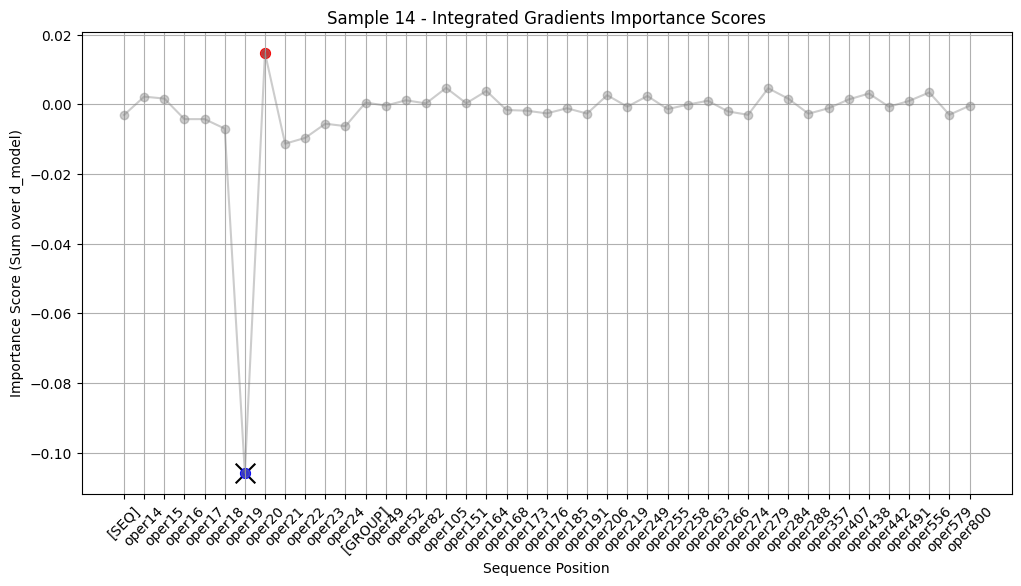

Oper IDs Length: 17, Valid Attr Length: 17
Sample 15 - 유효 시퀀스 길이: 17
Sample 15 - 중요도 합 (유효 위치): tensor([-0.0072,  0.0038, -0.0125, -0.0190, -0.0175, -0.0277,  0.4817, -0.0400,
        -0.0341, -0.0216, -0.0199, -0.0152,  0.1834,  0.0150,  0.0061,  0.0036,
        -0.0097])


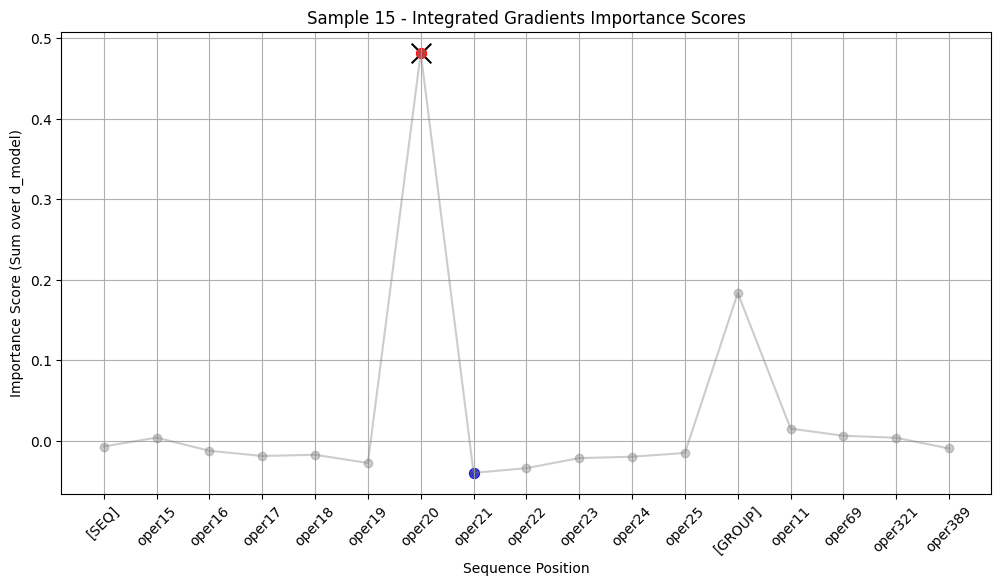

Oper IDs Length: 41, Valid Attr Length: 41
Sample 16 - 유효 시퀀스 길이: 41
Sample 16 - 중요도 합 (유효 위치): tensor([-0.0024, -0.0022, -0.0024, -0.0029, -0.0027,  0.0006, -0.1056, -0.0072,
        -0.0050, -0.0067, -0.0039, -0.0014,  0.0012, -0.0009, -0.0012, -0.0031,
        -0.0039, -0.0030, -0.0040, -0.0015, -0.0039, -0.0035, -0.0022, -0.0028,
        -0.0008, -0.0033, -0.0037, -0.0027, -0.0029,  0.0003, -0.0035, -0.0037,
        -0.0012, -0.0010, -0.0029, -0.0027, -0.0027, -0.0027, -0.0037, -0.0031,
        -0.0020])


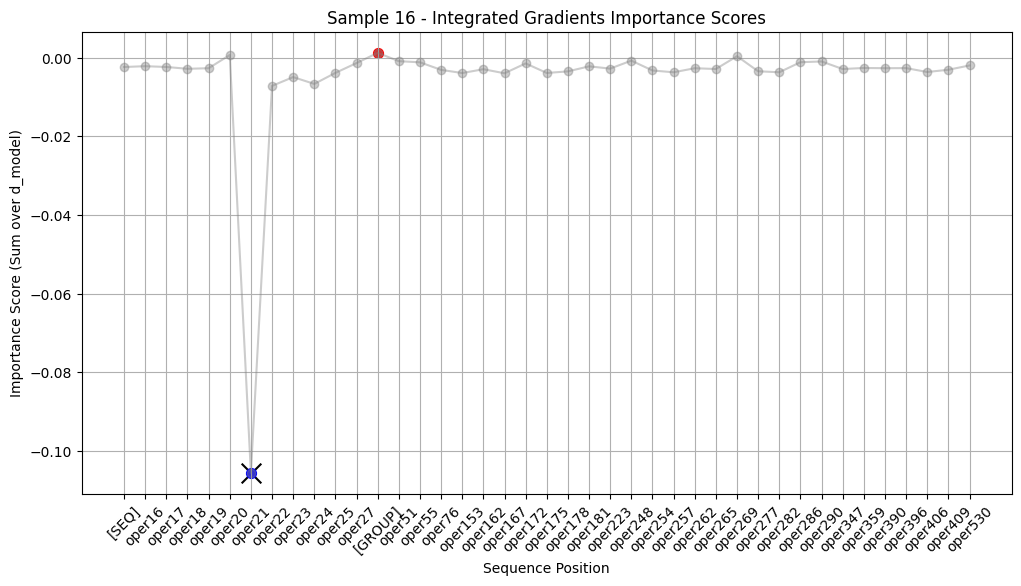

In [9]:
attributions = attributions.detach().cpu()

for batch_idx in range(config.get("batch_size", 16)):
    attr = attributions[batch_idx]  # [seq_len, d_model]
    attr_sum = attr.sum(dim=-1)  # [seq_len]
    
    # 마스크 적용 (유효한 위치만)
    valid_mask = new_masks[batch_idx].cpu().numpy()  # [seq_len]
    valid_attr_sum = attr_sum[valid_mask]  # 유효한 위치의 중요도 합
    
    # 공정 ID 정보
    sequence_length = sequence_lengths[batch_idx]
    oper_ids = ['[SEQ]'] + window_oper_ids[batch_idx][:config['window_size']] + ['[GROUP]'] + window_oper_ids[batch_idx][config['window_size']:sequence_length]
    print(f"Oper IDs Length: {len(oper_ids)}, Valid Attr Length: {valid_attr_sum.shape[0]}")

    print(f"Sample {batch_idx+1} - 유효 시퀀스 길이: {len(oper_ids)}")
    print(f"Sample {batch_idx+1} - 중요도 합 (유효 위치): {valid_attr_sum}")
    
    # 시퀀스 전체에 대한 중요도 시각화
    plt.figure(figsize=(12, 6))
    target_idx = 1 + config['window_size']//2
    target = [None] * len(oper_ids)
    target[target_idx] = valid_attr_sum[target_idx].item()  # 중앙값 강조

    # attributions max, min
    arg_max = np.argmax(valid_attr_sum.numpy())
    arg_min = np.argmin(valid_attr_sum.numpy())
    max_value = [None] * len(oper_ids)
    max_value[arg_max] = valid_attr_sum[arg_max].item()
    min_value = [None] * len(oper_ids)
    min_value[arg_min] = valid_attr_sum[arg_min].item()



    plt.plot(valid_attr_sum, marker='o', linestyle='-', color = 'gray', alpha=0.4)
    plt.scatter(range(len(oper_ids)), target, marker='x', color='black', label='Target', s=200)
    plt.scatter(range(len(oper_ids)), max_value, color='red', label='Max', s=50)
    plt.scatter(range(len(oper_ids)), min_value, color='blue', label='Min', s=50)
    plt.title(f'Sample {batch_idx+1} - Integrated Gradients Importance Scores')
    plt.xlabel('Sequence Position')
    plt.ylabel('Importance Score (Sum over d_model)')
    plt.xticks(ticks=np.arange(len(oper_ids)), labels=oper_ids, rotation=45)
    plt.grid()
    plt.show()

## 모든 테스트 샘플에 대해서 종합 비교

- 각 샘플 별로 oper_id 시퀀스의 길이는 동일하나 같은 그룹의 operation의 개수는 다름
- [GROUP] 이후의 요소들에 대해서는 비교가 무의미 할 수 있음
- 모든 테스트 샘플에 대한 비교를 위해서는 [SEQ]부터 [GROUP] 까지 중, 타겟 공정에서 상대적으로 몇 번째 떨어진 위치의 공정의 attribution을 확인함

In [10]:
from tqdm import tqdm
pbar = tqdm(test_loader, desc = "Attribution Calculation", total = len(test_loader))

attributions_list = []
valid_masks_list = []
valid_attributions_list = []

for batch in pbar:
    enc_out, attn_mask, targets, new_masks, timekeys, window_oper_ids, sequence_lengths, reference_oper_groups = model.get_inputs(batch, device)
    
    # # 모델 예측 수행
    predictions = model(enc_out, attn_mask)
    
    # baseline: 모든 feature를 0으로 설정
    baseline = torch.zeros_like(enc_out)

    # IntegratedGradients 적용
    ig = IntegratedGradients(wrapped_model)
    attributions = ig.attribute(
        inputs=enc_out,
        baselines=baseline,
        n_steps=50,
    )

    # attributions shape : (batch_size, seq_len, d_model) = (16,65,128)
    attributions = attributions.detach().cpu()
    attr_sum = attributions.sum(dim=-1)  # [batch_size, seq_len] = (16,65)

    valid_mask = new_masks.detach().cpu()  # [batch_size, seq_len] = (16,65)
    valid_attr_sum = attr_sum * valid_mask  # 유효한 위치의 중요도 합 (배치 단위로 마스크 적용)

    for batch_idx in range(batch['continuous_data'].shape[0]):        
        # 공정 ID 정보
        sequence_length = sequence_lengths[batch_idx]
        oper_ids = ['[SEQ]'] + window_oper_ids[batch_idx][:config['window_size']] + ['[GROUP]'] + window_oper_ids[batch_idx][config['window_size']:sequence_length]

    attributions_list.append(attributions)
    valid_masks_list.append(valid_mask)
    valid_attributions_list.append(valid_attr_sum)

Attribution Calculation: 100%|██████████| 9748/9748 [14:13<00:00, 11.42it/s]


In [11]:
attributions_all = torch.cat(attributions_list, dim=0)  # (num_samples, seq_len, d_model)
valid_masks_all = torch.cat(valid_masks_list, dim=0)  # (num_samples, seq_len)
valid_attributions_all = torch.cat(valid_attributions_list, dim=0)  # (num_samples, seq_len)
print(f"Attributions All Shape: {attributions_all.shape}")
print(f"Valid Masks All Shape: {valid_masks_all.shape}")
print(f"Valid Attributions All Shape: {valid_attributions_all.shape}")


Attributions All Shape: torch.Size([155954, 65, 128])
Valid Masks All Shape: torch.Size([155954, 65])
Valid Attributions All Shape: torch.Size([155954, 65])


### 시퀀스 위치별 평균 중요도

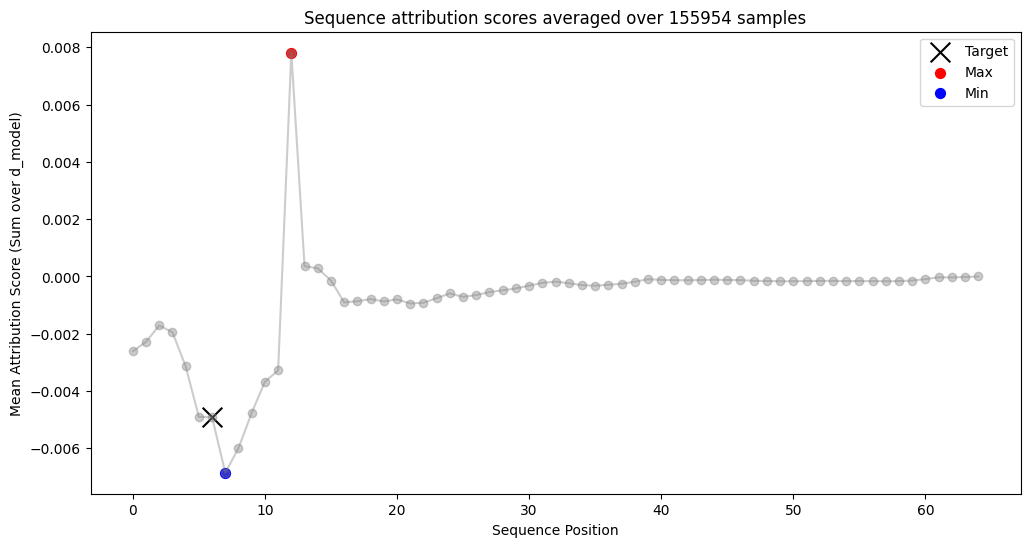

In [12]:
plt.figure(figsize=(12, 6))
mean_attr = valid_attributions_all.mean(dim=0) #.mean(dim=0)  # 시퀀스 위치별 평균 중요도
plt.plot(mean_attr, marker='o', linestyle='-', color = 'gray', alpha=0.4)
plt.title(f'Sequence attribution scores averaged over {valid_attributions_all.shape[0]} samples')
plt.xlabel('Sequence Position')
plt.ylabel('Mean Attribution Score (Sum over d_model)')

target_idx = 1 + config['window_size']//2
target = [None] * len(mean_attr)
target[target_idx] = mean_attr[target_idx].item()  # 중앙값 강조

# # attributions max, min
arg_max = np.argmax(mean_attr.numpy())
arg_min = np.argmin(mean_attr.numpy())
max_value = [None] * len(mean_attr)
max_value[arg_max] = mean_attr[arg_max].item()
min_value = [None] * len(mean_attr)
min_value[arg_min] = mean_attr[arg_min].item()

plt.scatter(range(len(mean_attr)), target, marker='x', color='black', label='Target', s=200)
plt.scatter(range(len(mean_attr)), max_value, color='red', label='Max', s=50)
plt.scatter(range(len(mean_attr)), min_value, color='blue', label='Min', s=50)
plt.legend()

## Captum의 KernelSHAP 활용
* KernelSHAP으로 변수 별 중요도 활용
* 단, 여기서 변수란 Transformer 모델에 들어가기 전 enc_out의 형태를 의미함

In [13]:
batch  = next(iter(test_loader))
enc_out, attn_mask, targets, new_masks, timekeys, window_oper_ids, sequence_lengths, reference_oper_groups = model.get_inputs(batch, device)

# 고정된 마스크로 모델 래핑
wrapped_model = FixedMaskModel(model, attn_mask)

# baseline: 모든 feature를 0으로 설정
baseline = torch.zeros_like(enc_out)

ks = KernelShap(wrapped_model)
attributions = ks.attribute(
    inputs = enc_out,
    baselines = baseline,
)
attributions = attributions.detach().cpu()
attributions = attributions.sum(dim=1)  # [batch_szie, seq_len]
print(f"attributions shape: {attributions.shape}")


attributions shape: torch.Size([16, 128])


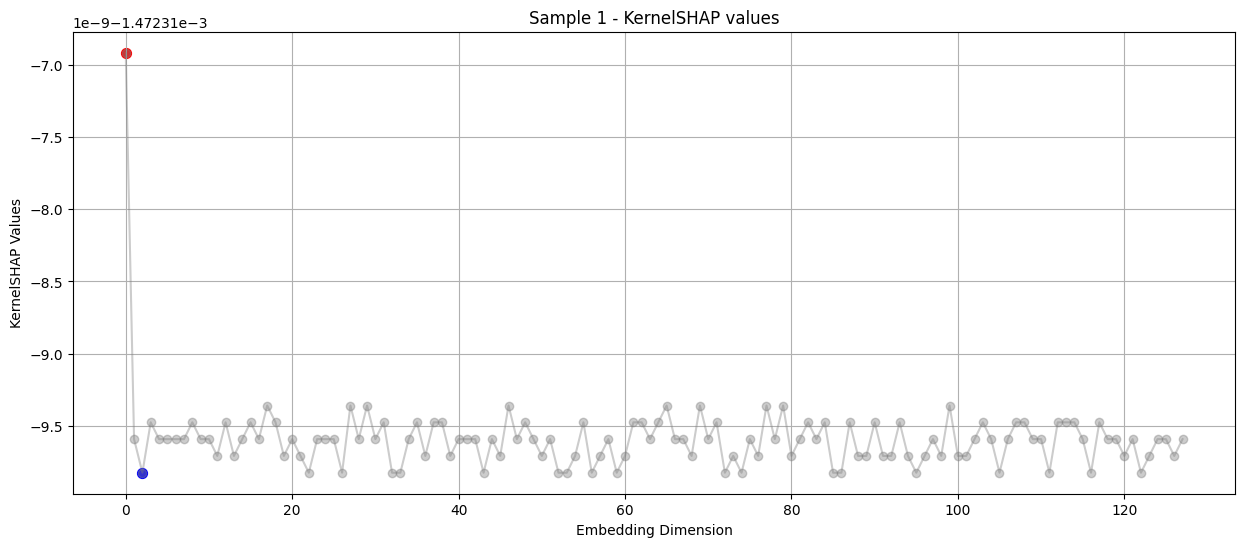

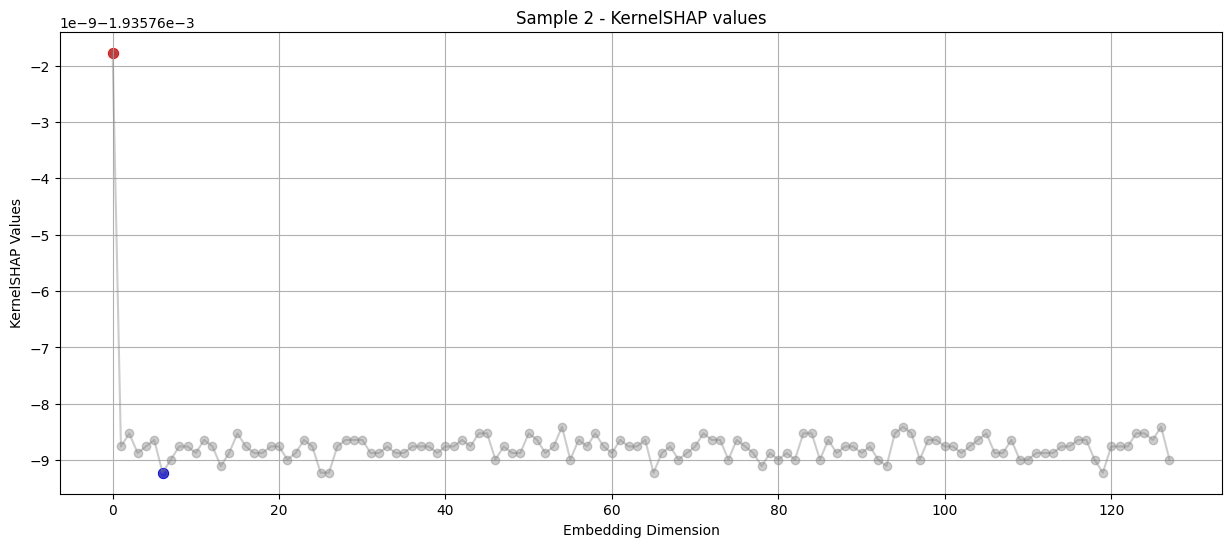

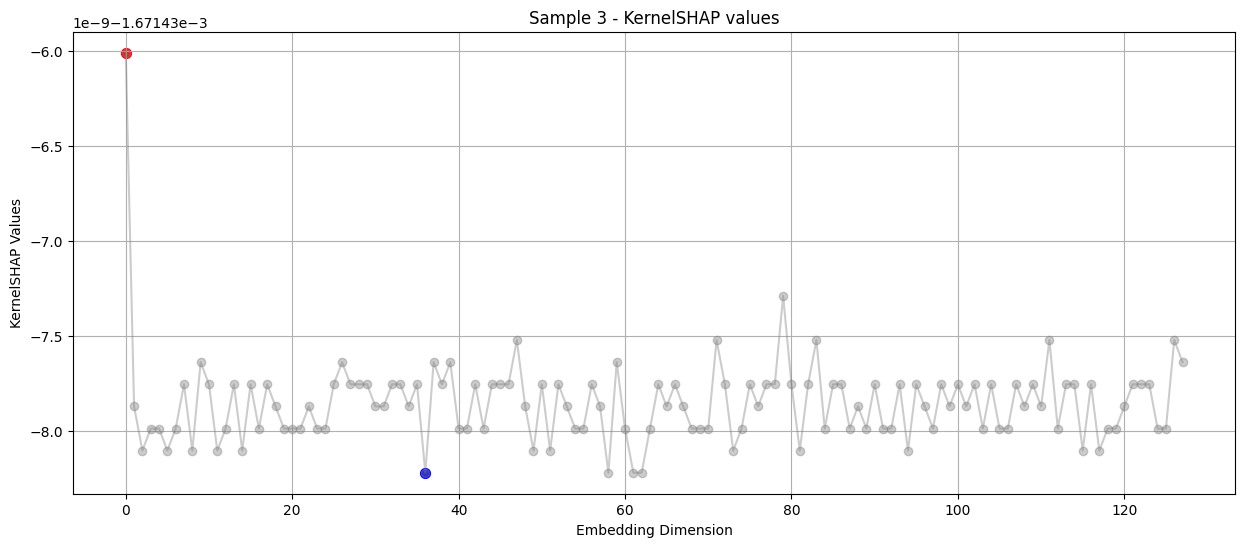

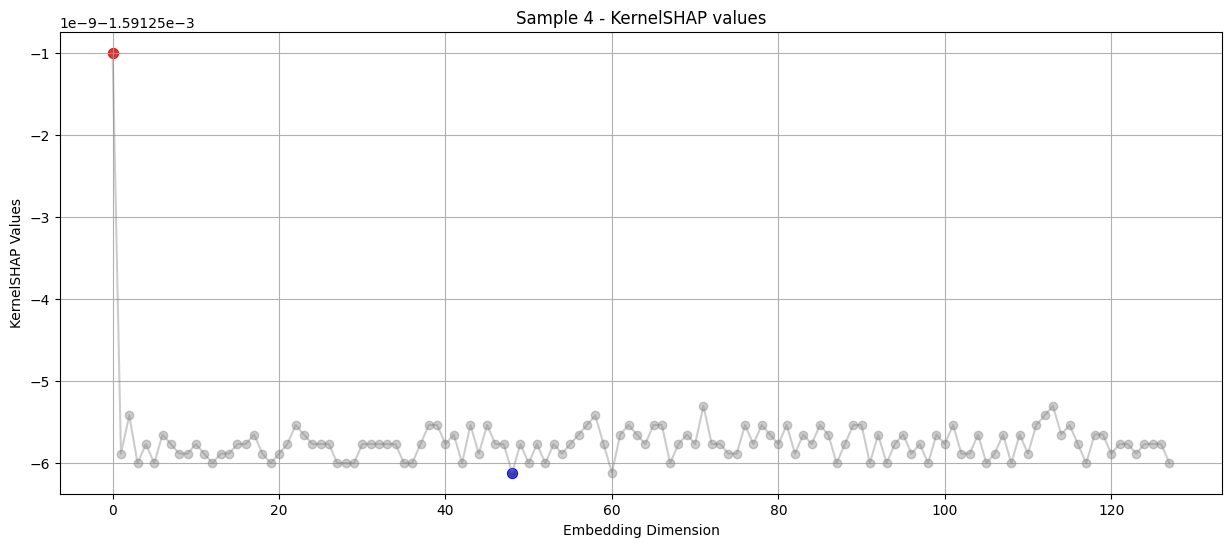

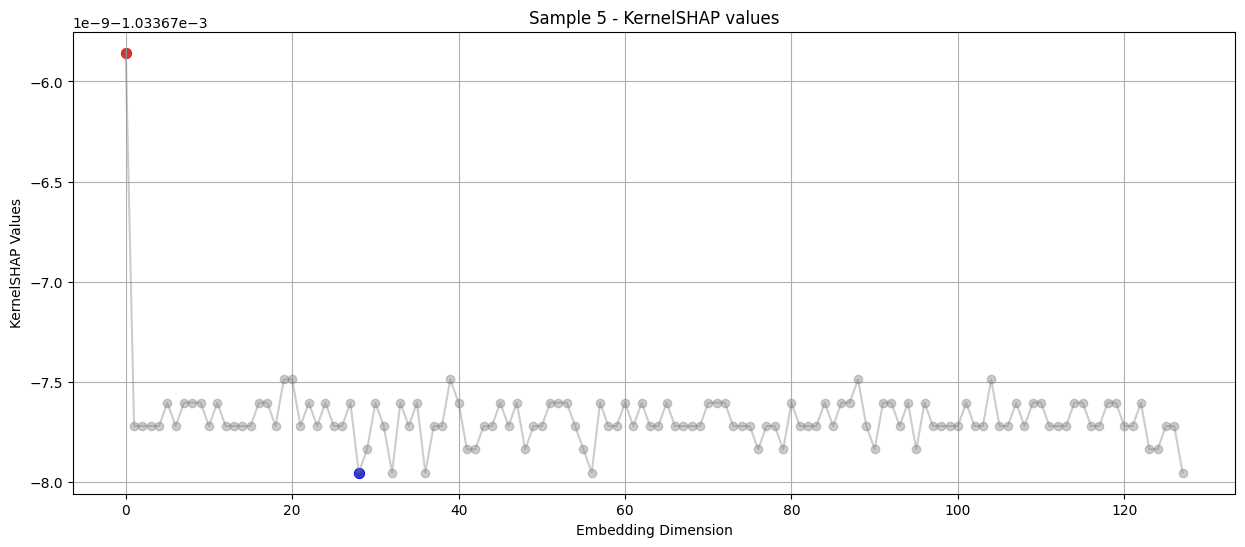

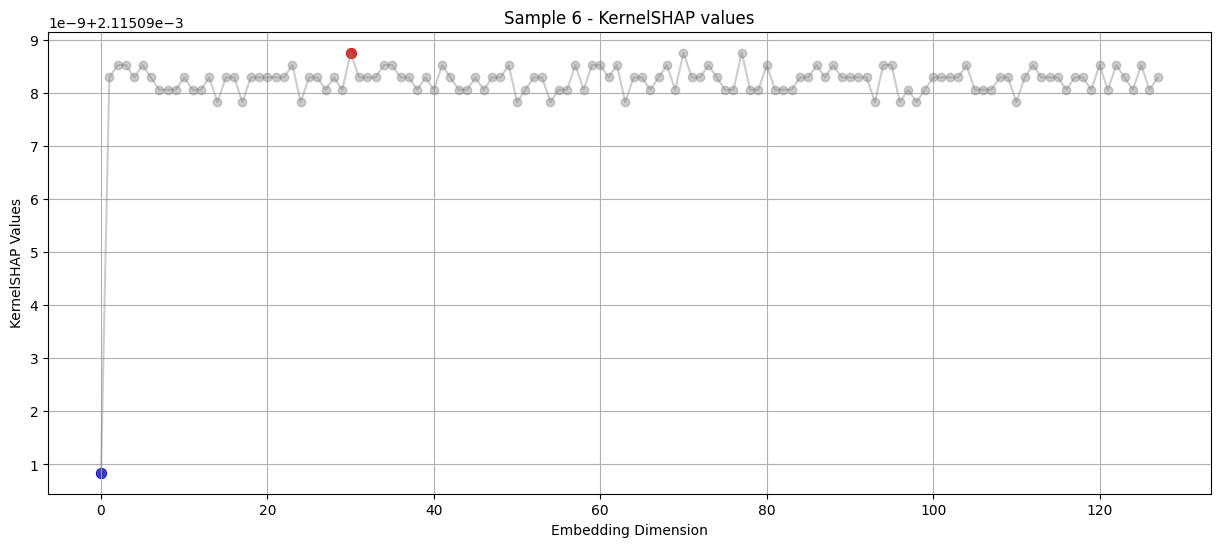

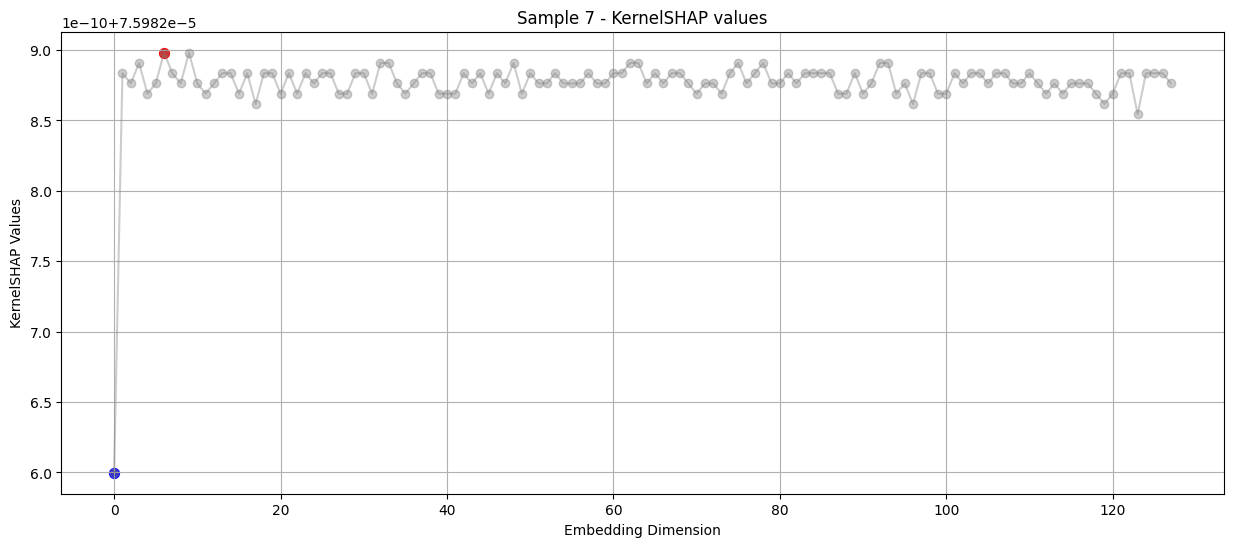

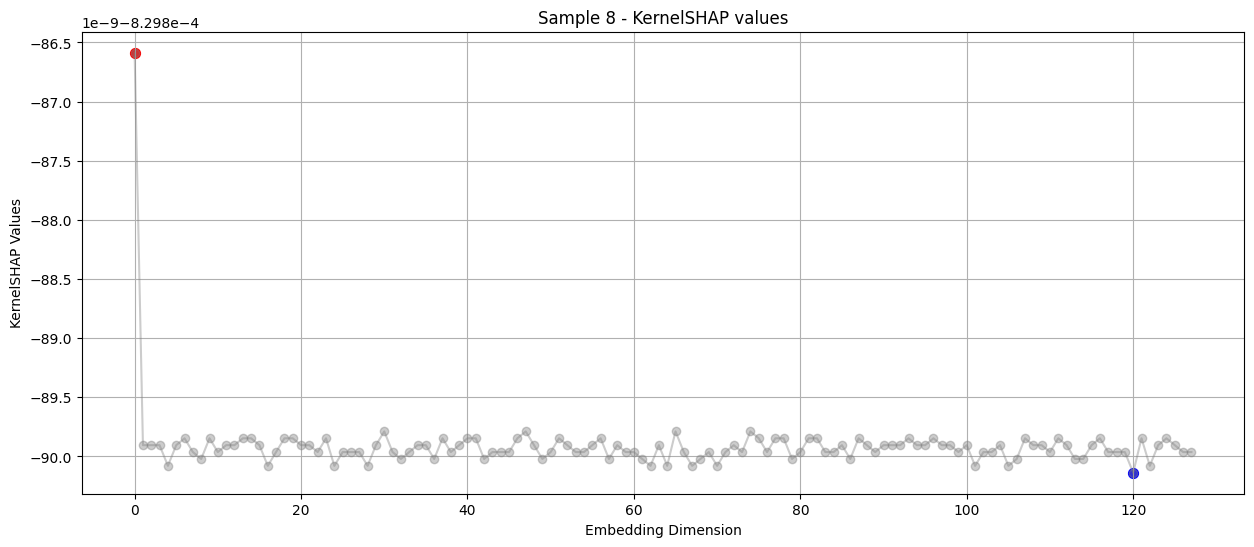

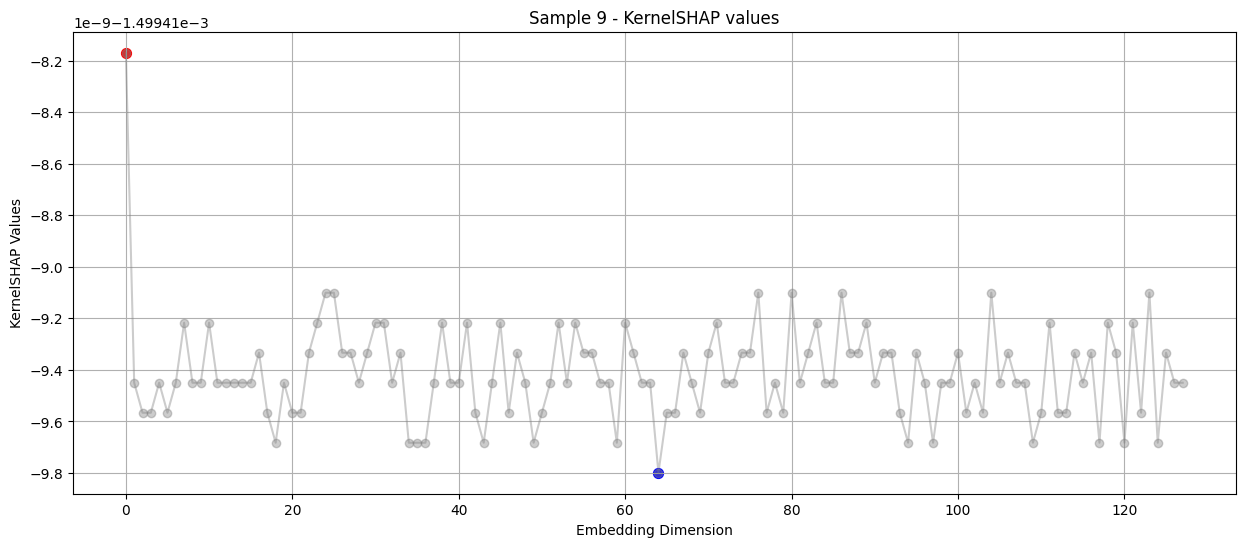

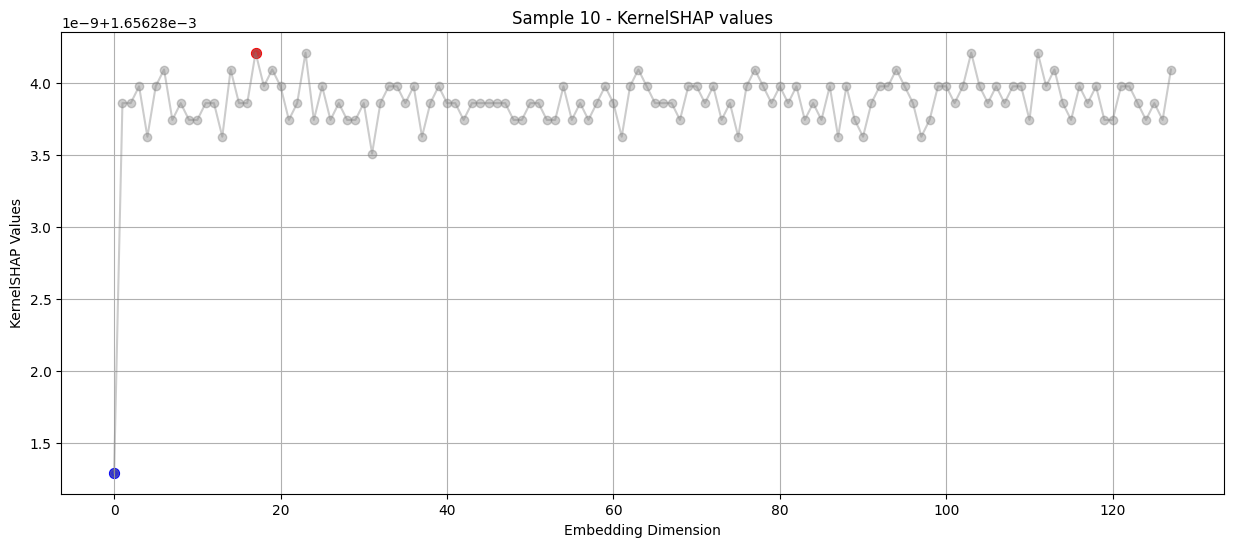

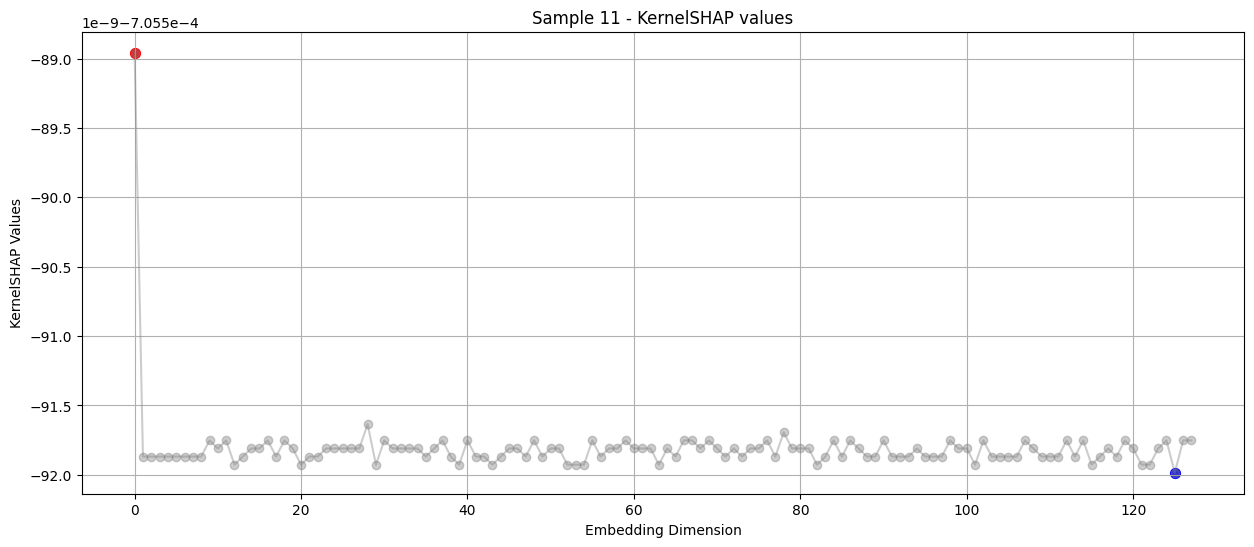

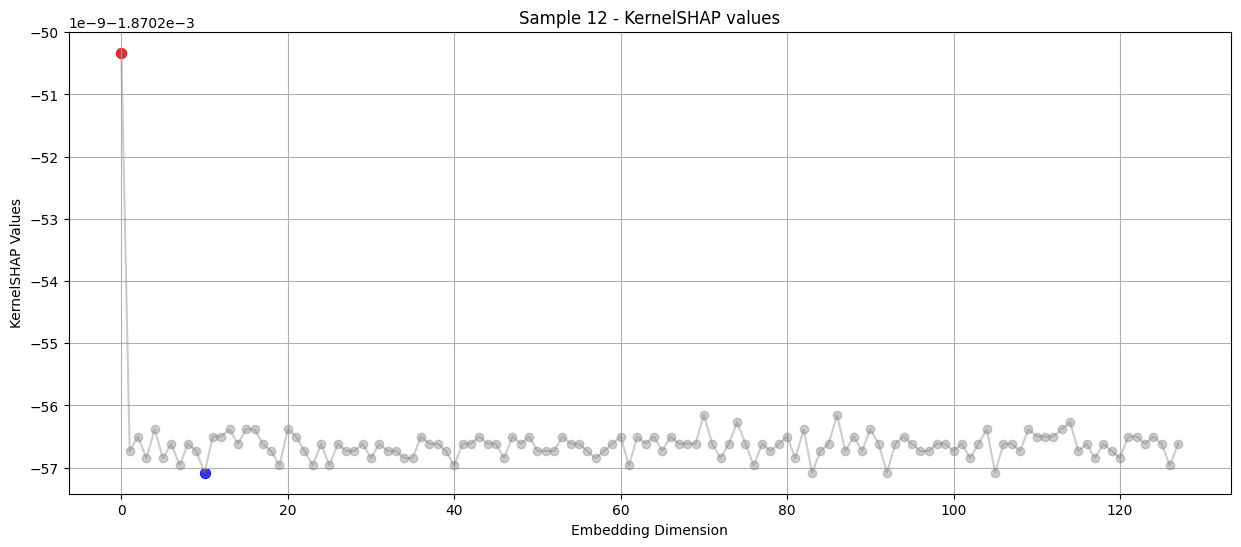

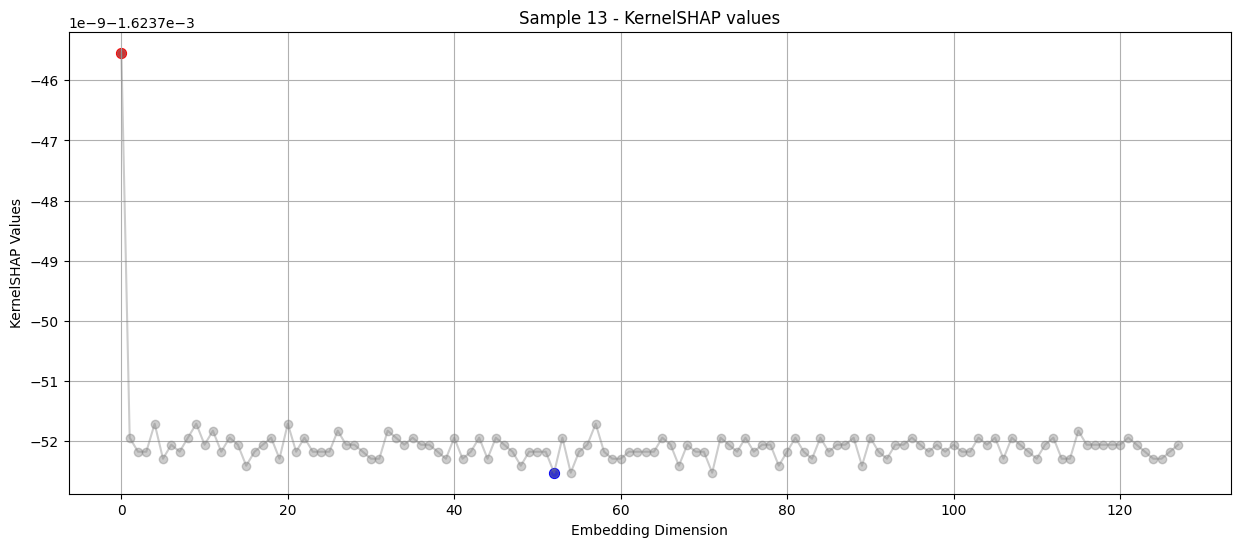

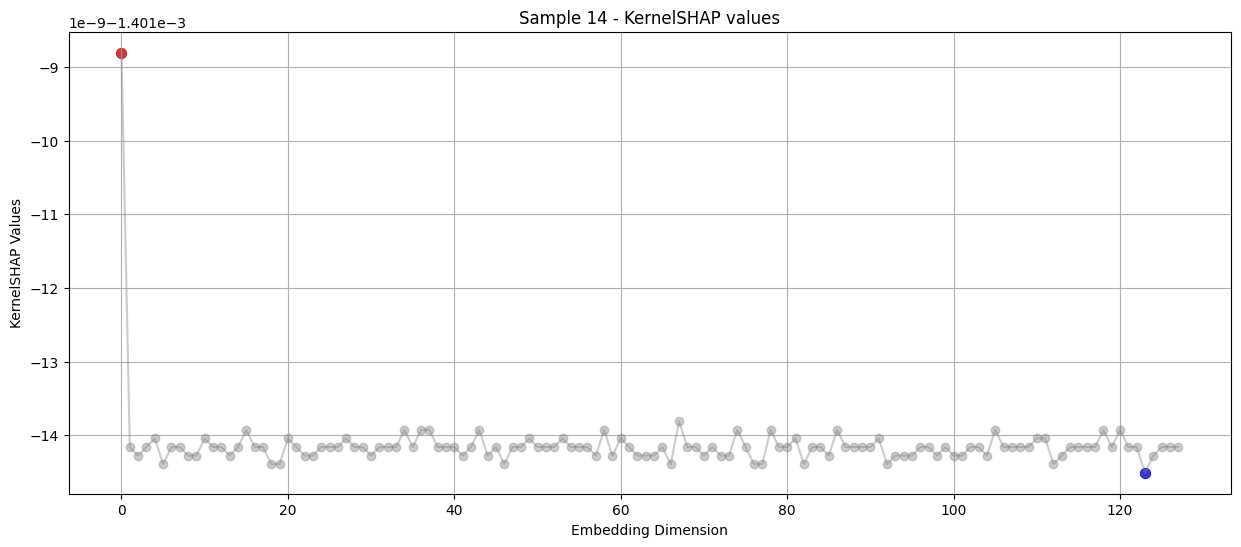

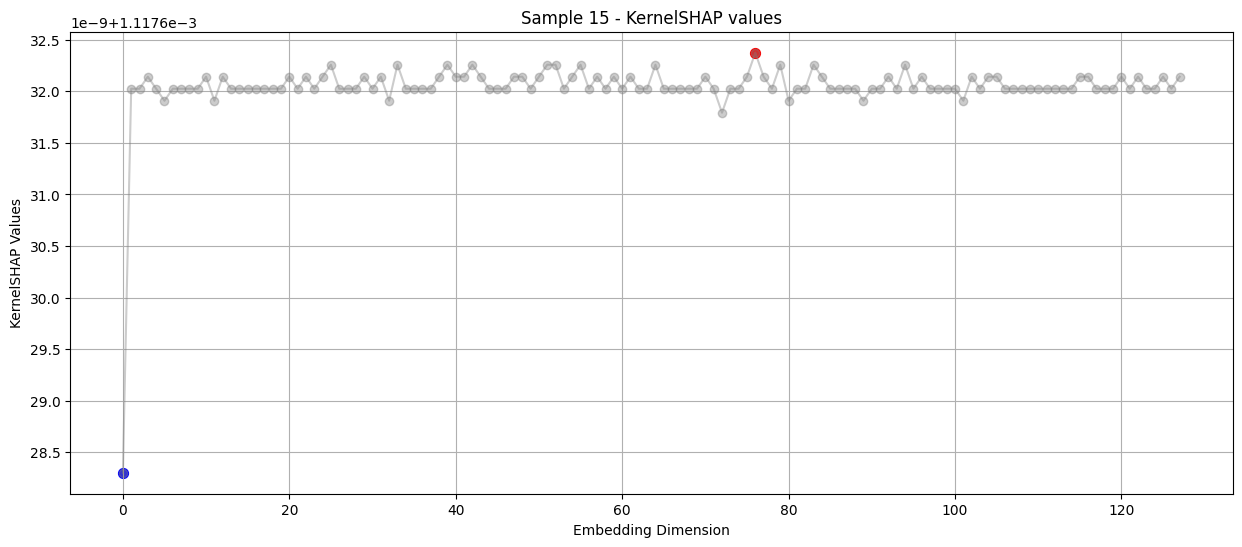

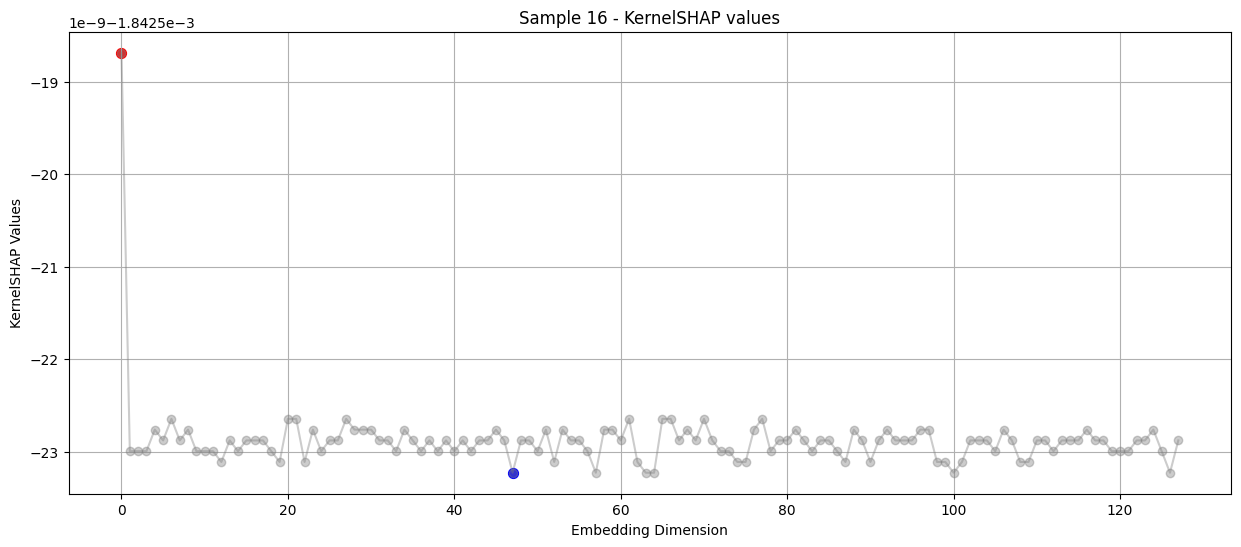

In [14]:
for batch_idx in range(config.get("batch_size", 16)):
    attr_sum = attributions[batch_idx]  # [dim_model]
    
    # 시퀀스 전체에 대한 중요도 시각화
    plt.figure(figsize=(15, 6))

    # attributions max, min
    arg_max = np.argmax(attr_sum.numpy())
    arg_min = np.argmin(attr_sum.numpy())
    max_value = [None] * len(attr_sum)
    max_value[arg_max] = attr_sum[arg_max].item()
    min_value = [None] * len(attr_sum)
    min_value[arg_min] = attr_sum[arg_min].item()



    plt.plot(attr_sum, marker='o', linestyle='-', color = 'gray', alpha=0.4)
    plt.scatter(range(len(attr_sum)), max_value, color='red', label='Max', s=50)
    plt.scatter(range(len(attr_sum)), min_value, color='blue', label='Min', s=50)
    plt.title(f'Sample {batch_idx+1} - KernelSHAP values')
    plt.xlabel('Embedding Dimension')
    plt.ylabel('KernelSHAP Values')
    plt.grid()
    plt.show()